In [ ]:
import pandas as pd
import glob
import gzip
import os
import pysam

ANNOVAR_PATH = (
    "/gpfs/data/user/shreyags/TE_work/"
    "replication_results/insertions_annotations/"
    "ALU_ensGene_annovar.hg38_multianno.txt"
)

ROADMAP_DIR = (
    "/gpfs/data/user/shreyags/TE_work/"
    "replication_results/insertions_annotations/roadmap/GI"
)

METADATA_PATH = (
    "/gpfs/data/user/shreyags/TE_work/"
    "filtered_vcfs/EID_roadmap_metadata.tab"
)

VCF_PATH = (
    "/gpfs/data/user/shreyags/TE_work/"
    "filtered_vcfs/with_af_new_final/"
    "ALU.filtered.final.tagged.vcf.gz"
)

OUTDIR = (
    "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_tables/"
)

os.makedirs(OUTDIR, exist_ok=True)

OUTFILE = (
    f"{OUTDIR}/af_all_ALU_all_insertions_full_annotation.csv"
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 1000)

def truncate_tissues(x, n=5):
    if pd.isna(x) or x == "NA":
        return x
    if not isinstance(x, str):
        return x
    if x == "":
        return "NA"
    items = x.split(", ")
    if len(items) <= n:
        return x
    return ", ".join(items[:n]) + f" ... (+{len(items)-n} more)"


print("Loading variants from VCF...")

vcf = pysam.VariantFile(VCF_PATH)
samples = list(vcf.header.samples)

carrier_counts = {}
hom_counts = {}
af_dict = {}
variant_rows = []

for rec in vcf.fetch():
    locus = f"{rec.chrom}:{rec.pos}"

    carriers = 0
    homs = 0

    for sample in samples:
        gt = rec.samples[sample]["GT"]
        if gt is None:
            continue
        alleles = [a for a in gt if a is not None]
        if len(alleles) == 0:
            continue
        if any(a > 0 for a in alleles):
            carriers += 1
        if len(alleles) == 2 and alleles[0] > 0 and alleles[1] > 0:
            homs += 1

    carrier_counts[locus] = carriers
    hom_counts[locus] = homs

    af = rec.info.get("AF")
    if isinstance(af, (list, tuple)):
        af = af[0]
    af_dict[locus] = af

    variant_rows.append({
        "Chr":   rec.chrom,
        "Start": rec.pos,
        "End":   rec.stop,
        "locus": locus
    })

vcf.close()

variants = pd.DataFrame(variant_rows)
print(f"{len(variants):,} variants loaded from VCF")

variants["AF"]          = variants["locus"].map(af_dict)
variants["n_carriers"]  = variants["locus"].map(carrier_counts).fillna(0).astype(int)
variants["n_homozygous"]= variants["locus"].map(hom_counts).fillna(0).astype(int)

print("Loading ANNOVAR...")

annovar = pd.read_csv(ANNOVAR_PATH, sep="\t", low_memory=False)
annovar.columns = annovar.columns.str.strip()
annovar["locus"] = annovar["Chr"] + ":" + annovar["Start"].astype(str)

annovar_keep = annovar[["locus", "Func.ensGene", "Gene.ensGene"]].copy()

variants = variants.merge(annovar_keep, on="locus", how="left")

print("Loading Roadmap metadata...")

meta_df = pd.read_csv(METADATA_PATH, sep="\t", usecols=["EID", "MNEMONIC"])
ROADMAP_LABELS = dict(zip(meta_df["EID"], meta_df["MNEMONIC"]))

print("Scanning Roadmap files...")

roadmap_files = sorted(glob.glob(f"{ROADMAP_DIR}/GI_ALU_E*_Roadmap.tsv.gz"))

locus_set = set(variants["locus"])
state_hits = {locus: {} for locus in locus_set}

for fpath in roadmap_files:
    ecode  = os.path.basename(fpath).split("_")[2]
    tissue = ROADMAP_LABELS.get(ecode, ecode)
    label  = f"{tissue}({ecode})"

    with gzip.open(fpath, "rt") as f:
        for line in f:
            parts = line.rstrip().split("\t")
            if len(parts) < 2:
                continue
            locus = parts[0]
            state = parts[1]
            if locus not in locus_set:
                continue
            state_hits[locus].setdefault(state, []).append(label)

print("Finished scanning Roadmap files")

all_states = sorted(
    {state for d in state_hits.values() for state in d.keys()}
)

print("\nStates observed:")
print(all_states)

for state in all_states:
    variants[f"{state}_tissues"] = variants["locus"].map(
        lambda l, s=state:
        ", ".join(sorted(set(state_hits[l].get(s, []))))
        if state_hits[l].get(s) else "NA"
    )
    variants[f"{state}_n_tissues"] = variants["locus"].map(
        lambda l, s=state:
        len(set(state_hits[l].get(s, [])))
        if state_hits[l].get(s) else 0
    )

print("\nState summary:")
state_summary = pd.DataFrame({
    "state":      all_states,
    "n_variants": [
        (variants[f"{state}_n_tissues"] > 0).sum()
        for state in all_states
    ]
})
display(state_summary.sort_values("n_variants", ascending=False))

variants.to_csv(OUTFILE, sep=",", index=False, na_rep="NA")
print(f"\nSaved: {OUTFILE}")

display_df = variants.copy()
tissue_cols = [
    c for c in display_df.columns
    if c.endswith("_tissues") and not c.endswith("_n_tissues")
]
for c in tissue_cols:
    display_df[c] = display_df[c].apply(truncate_tissues)

display(display_df)

Loading variants from VCF...


[W::bcf_hdr_check_sanity] GL should be declared as Number=G


26,977 variants loaded from VCF
Loading ANNOVAR...
Loading Roadmap metadata...
Scanning Roadmap files...
Finished scanning Roadmap files

States observed:
['10_TssBiv', '11_BivFlnk', '12_EnhBiv', '13_ReprPC', '14_ReprPCWk', '15_Quies', '1_TssA', '2_TssAFlnk', '3_TxFlnk', '4_Tx', '5_TxWk', '6_EnhG', '7_Enh', '8_ZNF/Rpts', '9_Het']

State summary:


,state,n_variants
5,15_Quies,26570
4,14_ReprPCWk,18691
10,5_TxWk,18481
14,9_Het,11745
12,7_Enh,11115
3,13_ReprPC,5005
9,4_Tx,4795
7,2_TssAFlnk,2308
11,6_EnhG,2221
13,8_ZNF/Rpts,1334



Saved: /gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_tables//af_all_ALU_all_insertions_full_annotation.csv


,Chr,Start,End,locus,AF,n_carriers,n_homozygous,Func.ensGene,Gene.ensGene,10_TssBiv_tissues,10_TssBiv_n_tissues,11_BivFlnk_tissues,11_BivFlnk_n_tissues,12_EnhBiv_tissues,12_EnhBiv_n_tissues,13_ReprPC_tissues,13_ReprPC_n_tissues,14_ReprPCWk_tissues,14_ReprPCWk_n_tissues,15_Quies_tissues,15_Quies_n_tissues,1_TssA_tissues,1_TssA_n_tissues,2_TssAFlnk_tissues,2_TssAFlnk_n_tissues,3_TxFlnk_tissues,3_TxFlnk_n_tissues,4_Tx_tissues,4_Tx_n_tissues,5_TxWk_tissues,5_TxWk_n_tissues,6_EnhG_tissues,6_EnhG_n_tissues,7_Enh_tissues,7_Enh_n_tissues,8_ZNF/Rpts_tissues,8_ZNF/Rpts_n_tissues,9_Het_tissues,9_Het_n_tissues
0,chr1,889640,889640,chr1:889640,0.000618,9,0,intergenic,"FAM41C,ENSG00000272438",NA,0,NA,0,NA,0,"BLD.K562.CNCR(E123), BRN.ANG.GYR(E067), BRN.CING.GYR(E069), BRN.DL.PRFRNTL.CRTX(E073), BRN.FET.F(E082) ... (+20 more)",25,"BRN.GRM.MTRX(E070), GI.L.INT.FET(E084), MUS.SKLT.M(E107), SKIN.PEN.FRSK.MEL.01(E059)",4,"BLD.CD4.MPC(E037), MUS.PSOAS(E100)",2,NA,0,NA,0,NA,0,NA,0,NA,0,NA,0,NA,0,"BLD.CD3.CPC(E033), BRN.FET.M(E081), CRVX.HELAS3.CNCR(E117), ESC.H1(E003), ESC.H9(E008) ... (+11 more)",16,"ADRL.GLND.FET(E080), BLD.CD14.MONO(E124), BLD.CD14.PC(E029), BLD.CD15.PC(E030), BLD.CD19.CPC(E031) ... (+75 more)",80
1,chr1,1188985,1188985,chr1:1188985,0.000549,8,0,intronic,TTLL10,NA,0,NA,0,NA,0,BONE.OSTEO(E129),1,"ADRL.GLND.FET(E080), BLD.CD15.PC(E030), BLD.CD19.CPC(E031), BLD.CD19.PPC(E032), BRN.CRTX.DR.NRSPHR(E053) ... (+35 more)",40,"BLD.CD14.PC(E029), BLD.CD3.CPC(E033), BLD.CD3.PPC(E034), BLD.CD4.CD25.CD127M.TREGPC(E044), BLD.CD4.CD25I.CD127.TMEMPC(E045) ... (+75 more)",80,NA,0,NA,0,NA,0,NA,0,"BLD.MOB.CD34.PC.F(E050), PANC(E098)",2,NA,0,"BLD.CD14.MONO(E124), BLD.CD34.CC(E036), BLD.CD34.PC(E035), BLD.MOB.CD34.PC.M(E051)",4,NA,0,NA,0
2,chr1,1412871,1412871,chr1:1412871,0.000069,1,0,intergenic,"MRPL20-DT,ANKRD65",NA,0,NA,0,NA,0,NA,0,"BLD.CD3.CPC(E033), BLD.CD3.PPC(E034), BLD.CD4.CD25M.CD45RO.MPC(E040), BRN.FET.F(E082), BRN.GRM.MTRX(E070) ... (+3 more)",8,"BLD.CD14.MONO(E124), BLD.CD19.CPC(E031), BLD.CD34.CC(E036), BLD.CD4.CD25.CD127M.TREGPC(E044), BLD.CD4.CD25I.CD127.TMEMPC(E045) ... (+50 more)",55,NA,0,NA,0,NA,0,BRST.MYO(E027),1,"BLD.CD19.PPC(E032), BLD.PER.MONUC.PC(E062), BRN.ANG.GYR(E067), BRN.ANT.CAUD(E068), BRN.CING.GYR(E069) ... (+40 more)",45,NA,0,NA,0,BLD.GM12878(E116),1,"ADRL.GLND.FET(E080), BLD.CD14.PC(E029), BLD.CD15.PC(E030), BLD.CD34.PC(E035), BLD.K562.CNCR(E123) ... (+12 more)",17
3,chr1,1786424,1786424,chr1:1786424,0.000275,4,0,UTR3,GNB1,NA,0,NA,0,NA,0,NA,0,NA,0,ESDR.H1.BMP4.MESO(E004),1,NA,0,NA,0,NA,0,"ADRL.GLND.FET(E080), BLD.CD14.MONO(E124), BLD.CD14.PC(E029), BLD.CD15.PC(E030), BLD.CD19.CPC(E031) ... (+115 more)",120,"GI.STMC.MUC(E110), HRT.ATR.R(E104), HRT.FET(E083), IPSC.DF.19.11(E022), MUS.PSOAS(E100)",5,FAT.ADIP.DR.MSC(E025),1,NA,0,NA,0,NA,0
4,chr1,1937257,1937257,chr1:1937257,0.000206,3,0,intronic,CFAP74,NA,0,NA,0,"BRST.MYO(E027), MUS.TRNK.FET(E089)",2,"ADRL.GLND.FET(E080), BLD.CD3.PPC(E034), BRN.FET.M(E081), FAT.ADIP.DR.MSC(E025), FAT.MSC.DR.ADIP(E023) ... (+12 more)",17,"BLD.CD15.PC(E030), BLD.CD34.CC(E036), BLD.K562.CNCR(E123), BLD.MOB.CD34.PC.M(E051), BONE.OSTEO(E129) ... (+34 more)",39,"BLD.CD14.MONO(E124), BLD.CD14.PC(E029), BLD.CD19.CPC(E031), BLD.CD19.PPC(E032), BLD.CD3.CPC(E033) ... (+58 more)",63,NA,0,NA,0,NA,0,NA,0,"GI.STMC.GAST(E094), HRT.ATR.R(E104), SPLN(E113)",3,NA,0,"LIV.HEPG2.CNCR(E118), LNG(E096)",2,IPSC.DF.19.11(E022),1,NA,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26972,chrX,155781597,155781597,chrX:155781597,0.000137,2,0,UTR3,SPRY3,NA,0,NA,0,NA,0,NA,0,BRST.MYO(E027),1,"ADRL.GLND.FET(E080), BLD.CD14.MONO(E124), BLD.CD14.PC(E029), BLD.CD15.PC(E030), BLD.CD19.CPC(E031) ... (+110 more)",115,NA,0,NA,0,NA,0,NA,0,NA,0,NA,0,NA,0,NA,0,"BRN.GRM.MTRX(E070), ESC.4STAR(E024), ESC.H1(E003), ESC.HUES48(E014), ESC.HUES64(E016) ... (+6 more)",11
26973,chrX,155790214,155790214,chrX:155790214,0.000412,6,

In [ ]:
import pandas as pd
import glob
import gzip
import os
import pysam

ANNOVAR_PATH = (
    "/gpfs/data/user/shreyags/TE_work/"
    "replication_results/insertions_annotations/"
    "LINE1_ensGene_annovar.hg38_multianno.txt"
)

ROADMAP_DIR = (
    "/gpfs/data/user/shreyags/TE_work/"
    "replication_results/insertions_annotations/roadmap/GI"
)

METADATA_PATH = (
    "/gpfs/data/user/shreyags/TE_work/"
    "filtered_vcfs/EID_roadmap_metadata.tab"
)

VCF_PATH = (
    "/gpfs/data/user/shreyags/TE_work/"
    "filtered_vcfs/with_af_new_final/"
    "LINE1.filtered.final.tagged.vcf.gz"
)

OUTDIR = (
    "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_tables/"
)

os.makedirs(OUTDIR, exist_ok=True)

OUTFILE = (
    f"{OUTDIR}/af_all_LINE1_all_insertions_full_annotation.csv"
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 1000)

def truncate_tissues(x, n=5):
    if pd.isna(x) or x == "NA":
        return x
    if not isinstance(x, str):
        return x
    if x == "":
        return "NA"
    items = x.split(", ")
    if len(items) <= n:
        return x
    return ", ".join(items[:n]) + f" ... (+{len(items)-n} more)"


print("Loading variants from VCF...")

vcf = pysam.VariantFile(VCF_PATH)
samples = list(vcf.header.samples)

carrier_counts = {}
hom_counts = {}
af_dict = {}
variant_rows = []

for rec in vcf.fetch():
    locus = f"{rec.chrom}:{rec.pos}"

    carriers = 0
    homs = 0

    for sample in samples:
        gt = rec.samples[sample]["GT"]
        if gt is None:
            continue
        alleles = [a for a in gt if a is not None]
        if len(alleles) == 0:
            continue
        if any(a > 0 for a in alleles):
            carriers += 1
        if len(alleles) == 2 and alleles[0] > 0 and alleles[1] > 0:
            homs += 1

    carrier_counts[locus] = carriers
    hom_counts[locus] = homs

    af = rec.info.get("AF")
    if isinstance(af, (list, tuple)):
        af = af[0]
    af_dict[locus] = af

    variant_rows.append({
        "Chr":   rec.chrom,
        "Start": rec.pos,
        "End":   rec.stop,
        "locus": locus
    })

vcf.close()

variants = pd.DataFrame(variant_rows)
print(f"{len(variants):,} variants loaded from VCF")

variants["AF"]          = variants["locus"].map(af_dict)
variants["n_carriers"]  = variants["locus"].map(carrier_counts).fillna(0).astype(int)
variants["n_homozygous"]= variants["locus"].map(hom_counts).fillna(0).astype(int)

print("Loading ANNOVAR...")

annovar = pd.read_csv(ANNOVAR_PATH, sep="\t", low_memory=False)
annovar.columns = annovar.columns.str.strip()
annovar["locus"] = annovar["Chr"] + ":" + annovar["Start"].astype(str)

annovar_keep = annovar[["locus", "Func.ensGene", "Gene.ensGene"]].copy()

variants = variants.merge(annovar_keep, on="locus", how="left")

print("Loading Roadmap metadata...")

meta_df = pd.read_csv(METADATA_PATH, sep="\t", usecols=["EID", "MNEMONIC"])
ROADMAP_LABELS = dict(zip(meta_df["EID"], meta_df["MNEMONIC"]))

print("Scanning Roadmap files...")

roadmap_files = sorted(glob.glob(f"{ROADMAP_DIR}/GI_LINE1_E*_Roadmap.tsv.gz"))

locus_set = set(variants["locus"])
state_hits = {locus: {} for locus in locus_set}

for fpath in roadmap_files:
    ecode  = os.path.basename(fpath).split("_")[2]
    tissue = ROADMAP_LABELS.get(ecode, ecode)
    label  = f"{tissue}({ecode})"

    with gzip.open(fpath, "rt") as f:
        for line in f:
            parts = line.rstrip().split("\t")
            if len(parts) < 2:
                continue
            locus = parts[0]
            state = parts[1]
            if locus not in locus_set:
                continue
            state_hits[locus].setdefault(state, []).append(label)

print("Finished scanning Roadmap files")

all_states = sorted(
    {state for d in state_hits.values() for state in d.keys()}
)

print("\nStates observed:")
print(all_states)

for state in all_states:
    variants[f"{state}_tissues"] = variants["locus"].map(
        lambda l, s=state:
        ", ".join(sorted(set(state_hits[l].get(s, []))))
        if state_hits[l].get(s) else "NA"
    )
    variants[f"{state}_n_tissues"] = variants["locus"].map(
        lambda l, s=state:
        len(set(state_hits[l].get(s, [])))
        if state_hits[l].get(s) else 0
    )

print("\nState summary:")
state_summary = pd.DataFrame({
    "state":      all_states,
    "n_variants": [
        (variants[f"{state}_n_tissues"] > 0).sum()
        for state in all_states
    ]
})
display(state_summary.sort_values("n_variants", ascending=False))

variants.to_csv(OUTFILE, sep=",", index=False, na_rep="NA")
print(f"\nSaved: {OUTFILE}")

display_df = variants.copy()
tissue_cols = [
    c for c in display_df.columns
    if c.endswith("_tissues") and not c.endswith("_n_tissues")
]
for c in tissue_cols:
    display_df[c] = display_df[c].apply(truncate_tissues)

display(display_df)

Loading variants from VCF...
7,075 variants loaded from VCF
Loading ANNOVAR...
Loading Roadmap metadata...
Scanning Roadmap files...
Finished scanning Roadmap files

States observed:
['10_TssBiv', '11_BivFlnk', '12_EnhBiv', '13_ReprPC', '14_ReprPCWk', '15_Quies', '1_TssA', '2_TssAFlnk', '3_TxFlnk', '4_Tx', '5_TxWk', '6_EnhG', '7_Enh', '8_ZNF/Rpts', '9_Het']

State summary:


,state,n_variants
5,15_Quies,6948
4,14_ReprPCWk,5155
10,5_TxWk,4579
14,9_Het,3140
12,7_Enh,3101
3,13_ReprPC,1232
9,4_Tx,926
7,2_TssAFlnk,546
11,6_EnhG,358
6,1_TssA,306



Saved: /gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_tables//af_all_LINE1_all_insertions_full_annotation.csv


,Chr,Start,End,locus,AF,n_carriers,n_homozygous,Func.ensGene,Gene.ensGene,10_TssBiv_tissues,10_TssBiv_n_tissues,11_BivFlnk_tissues,11_BivFlnk_n_tissues,12_EnhBiv_tissues,12_EnhBiv_n_tissues,13_ReprPC_tissues,13_ReprPC_n_tissues,14_ReprPCWk_tissues,14_ReprPCWk_n_tissues,15_Quies_tissues,15_Quies_n_tissues,1_TssA_tissues,1_TssA_n_tissues,2_TssAFlnk_tissues,2_TssAFlnk_n_tissues,3_TxFlnk_tissues,3_TxFlnk_n_tissues,4_Tx_tissues,4_Tx_n_tissues,5_TxWk_tissues,5_TxWk_n_tissues,6_EnhG_tissues,6_EnhG_n_tissues,7_Enh_tissues,7_Enh_n_tissues,8_ZNF/Rpts_tissues,8_ZNF/Rpts_n_tissues,9_Het_tissues,9_Het_n_tissues
0,chr1,4678261,4678261,chr1:4678261,0.000069,1,0,intronic,AJAP1,NA,0,NA,0,NA,0,ADRL.GLND.FET(E080),1,"BLD.CD3.PPC(E034), BLD.PER.MONUC.PC(E062), CRVX.HELAS3.CNCR(E117), ESDR.H9.NEUR(E010), GI.S.INT(E109) ... (+1 more)",6,"BLD.CD14.MONO(E124), BLD.CD15.PC(E030), BLD.CD19.CPC(E031), BLD.CD19.PPC(E032), BLD.CD3.CPC(E033) ... (+42 more)",47,BRN.CING.GYR(E069),1,NA,0,NA,0,NA,0,"BRN.ANG.GYR(E067), BRN.DL.PRFRNTL.CRTX(E073)",2,NA,0,NA,0,"BRN.HIPP.MID(E071), BRN.INF.TMP(E072), BRN.SUB.NIG(E074), ESDR.CD184.ENDO(E011), ESDR.H1.BMP4.TROP(E005) ... (+2 more)",7,"BLD.CD14.PC(E029), BLD.CD4.CD25.CD127M.TREGPC(E044), BLD.DND41.CNCR(E115), BLD.MOB.CD34.PC.F(E050), BLD.MOB.CD34.PC.M(E051) ... (+58 more)",63
1,chr1,4926318,4926318,chr1:4926318,0.000343,5,0,intergenic,"AJAP1,ENSG00000284739",NA,0,NA,0,NA,0,NA,0,"ADRL.GLND.FET(E080), BLD.CD3.PPC(E034), BLD.CD4.CD25M.TPC(E043), BLD.MOB.CD34.PC.F(E050), BLD.MOB.CD34.PC.M(E051) ... (+19 more)",24,"BLD.CD14.MONO(E124), BLD.CD14.PC(E029), BLD.CD15.PC(E030), BLD.CD19.CPC(E031), BLD.CD19.PPC(E032) ... (+86 more)",91,NA,0,NA,0,NA,0,NA,0,PANC(E098),1,NA,0,NA,0,NA,0,"BRST.HMEC.35(E028), ESDR.H1.MSC(E006), IPSC.DF.19.11(E022), IPSC.DF.6.9(E021), LIV.HEPG2.CNCR(E118) ... (+6 more)",11
2,chr1,4971696,4971696,chr1:4971696,0.000069,1,0,ncRNA_intronic,ENSG00000284739,NA,0,NA,0,NA,0,NA,0,"ADRL.GLND.FET(E080), BLD.CD3.PPC(E034), BLD.MOB.CD34.PC.F(E050), BLD.MOB.CD34.PC.M(E051), BRN.ANG.GYR(E067) ... (+30 more)",35,"BLD.CD14.MONO(E124), BLD.CD14.PC(E029), BLD.CD15.PC(E030), BLD.CD19.CPC(E031), BLD.CD19.PPC(E032) ... (+73 more)",78,NA,0,NA,0,NA,0,NA,0,HRT.ATR.R(E104),1,NA,0,SPLN(E113),1,NA,0,"BRN.NHA(E125), IPSC.DF.19.11(E022), LNG.IMR90(E017), LNG.NHLF(E128), PLCNT.FET(E091) ... (+7 more)",12
3,chr1,5312895,5312895,chr1:5312895,0.001373,19,1,intergenic,"ENSG00000284616,ENSG00000284666",NA,0,NA,0,NA,0,"ADRL.GLND.FET(E080), CRVX.HELAS3.CNCR(E117), GI.STMC.FET(E092), MUS.SKLT.M(E107), MUS.TRNK.FET(E089)",5,"BLD.CD3.PPC(E034), BLD.MOB.CD34.PC.F(E050), BLD.MOB.CD34.PC.M(E051), BRN.ANG.GYR(E067), BRN.ANT.CAUD(E068) ... (+26 more)",31,"BLD.CD14.MONO(E124), BLD.CD14.PC(E029), BLD.CD15.PC(E030), BLD.CD19.CPC(E031), BLD.CD19.PPC(E032) ... (+69 more)",74,NA,0,NA,0,NA,0,NA,0,NA,0,NA,0,"ESDR.CD56.ECTO(E012), ESDR.H1.NEUR.PROG(E007)",2,NA,0,"BRN.NHA(E125), BRST.HMEC(E119), ESDR.H1.MSC(E006), IPSC.DF.19.11(E022), LNG.IMR90(E017) ... (+10 more)",15
4,chr1,5333372,5333372,chr1:5333372,0.000069,1,0,intergenic,"ENSG00000284616,ENSG00000284666",NA,0,NA,0,NA,0,NA,0,"BLD.CD3.PPC(E034), BLD.MOB.CD34.PC.M(E051), BRN.ANG.GYR(E067), BRN.CING.GYR(E069), BRN.CRTX.DR.NRSPHR(E053) ... (+18 more)",23,"BLD.CD14.MONO(E124), BLD.CD14.PC(E029), BLD.CD15.PC(E030), BLD.CD19.CPC(E031), BLD.CD19.PPC(E032) ... (+72 more)",77,NA,0,NA,0,NA,0,NA,0,"BLD.CD4.CD25M.CD45RA.NPC(E039), BLD.CD4.CD25M.IL17M.PL.TPC(E041), BLD.CD4.CD25M.TPC(E043), BLD.CD4.NPC(E038), BLD.CD8.NPC(E047)",5,NA,0,"ADRL.GLND.FET(E080), GI.L.INT.FET(E084)",2,NA,0,"BRN.NHA(E125), BRST.HMEC(E119), ESC.HUES48(E014), ESDR.H1.BMP4.TROP(E005), ESDR.H1.MSC(E006) ... (+15 more)",20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7070,chrX,152843035,152843035,chrX:152843035,0.000275,2,2,intronic,NSDHL,NA,0,NA,0,NA,0,BRST.MYO(E027),1,NA,0,"BLD.CD4.CD25M.CD45RA.NPC(E039), BLD.CD4.CD25M.CD45RO.MPC

In [ ]:
import pandas as pd
from pathlib import Path

BASE_DIRS = {
    "all":    "/gpfs/data/user/shreyags/TE_work/replication_results/new_enrichment/insertions/all/",
    "common": "/gpfs/data/user/shreyags/TE_work/replication_results/new_enrichment/insertions/common/",
}

TE_TYPES = ["ALU", "LINE1"]

# Columns to pull from each tsv
KEEP_COLS = ["tissue_id", "tissue_name", "odds_ratio", "ci_lower", "ci_upper", "pvalue"]

all_rows = []

for dataset_label, base_dir in BASE_DIRS.items():
    base_path = Path(base_dir)

    for te in TE_TYPES:
        te_dir = base_path / te

        if not te_dir.is_dir():
            print(f"WARNING: {te_dir} not found, skipping")
            continue

        for tsv_file in te_dir.glob("*.tsv"):
            category = tsv_file.stem  # e.g. "1_TssA", "enhancers", "active"

            try:
                df = pd.read_csv(tsv_file, sep="\t")
            except Exception as e:
                print(f"Failed to read {tsv_file}: {e}")
                continue

            present_cols = [c for c in KEEP_COLS if c in df.columns]
            missing_cols = [c for c in KEEP_COLS if c not in df.columns]
            if missing_cols:
                print(f"{tsv_file} missing columns: {missing_cols}")

            sub = df[present_cols].copy()
            sub["dataset"] = dataset_label
            sub["te_type"] = te
            sub["category"] = category

            all_rows.append(sub)

combined = pd.concat(all_rows, ignore_index=True)

col_order = ["dataset", "te_type", "category", "tissue_id", "tissue_name",
              "odds_ratio", "ci_lower", "ci_upper", "pvalue", "FDR"]
col_order = [c for c in col_order if c in combined.columns]
combined = combined[col_order]

print(f"Total rows: {len(combined)}")
print(combined.head())

combined.to_csv("/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_tables/combined_enrichment_results.csv", index=False)
print("Saved to combined_enrichment_results.csv")

Total rows: 10160
  dataset te_type category tissue_id   tissue_name  odds_ratio  ci_lower  ci_upper         pvalue
0     all     ALU   active      E022          IPSC    0.703438  0.680440  0.727059  1.253002e-104
1     all     ALU   active      E104         HEART    0.769553  0.743089  0.796776   1.889967e-52
2     all     ALU   active      E113        SPLEEN    0.806953  0.781861  0.832715   9.431317e-43
3     all     ALU   active      E089        MUSCLE    0.867963  0.841340  0.895314   1.047203e-19
4     all     ALU   active      E079  GI_ESOPHAGUS    0.869511  0.842668  0.897097   5.210608e-19
Saved to combined_enrichment_results.csv


In [ ]:
VARIANTS_FILE = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_tables/af_all_ALU_all_insertions_full_annotation.csv"

STATES = [
    "1_TssA",
    "2_TssAFlnk",
    "3_TxFlnk",
    "4_Tx",
    "5_TxWk",
    "6_EnhG",
    "7_Enh",
    #"8_ZNF_Rpts",
    #"9_Het",
    "10_TssBiv",
    "11_BivFlnk",
    "12_EnhBiv",
    #"13_ReprPC",
    #"14_ReprPCWk",
    #"15_Quies",
]

MIN_TISSUES = 100         
FUNC_CATEGORY = None      # e.g. ANNOVAR categories

variants = pd.read_csv(VARIANTS_FILE, sep=",", low_memory=False)

available = sorted(
    c[:-len("_n_tissues")]
    for c in variants.columns
    if c.endswith("_n_tissues")
)

missing = [s for s in STATES if f"{s}_n_tissues" not in variants.columns]
if missing:
    raise ValueError(
        f"Missing state column(s): {missing}\nAvailable states:\n{available}"
    )


state_cols = [f"{s}_n_tissues" for s in STATES]
variants["state_total_tissues"] = variants[state_cols].sum(axis=1)

# Filter
mask = variants["state_total_tissues"] >= MIN_TISSUES

if FUNC_CATEGORY is not None:
    mask &= variants["Func.ensGene"] == FUNC_CATEGORY

result = variants[mask]

print(
    f"Loaded annotation file: {VARIANTS_FILE}\n"
    f"{len(result):,} / {len(variants):,} insertions present in the selected states "
    f"in >= {MIN_TISSUES} total tissues"
    + (
        f", restricted to Func.ensGene == '{FUNC_CATEGORY}'"
        if FUNC_CATEGORY else ""
    )
)

display(result[["state_total_tissues"] + state_cols].head())

display(result.head())

Loaded annotation file: /gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_tables/af_all_ALU_all_insertions_full_annotation.csv
2,618 / 26,977 insertions present in the selected states in >= 100 total tissues


,state_total_tissues,1_TssA_n_tissues,2_TssAFlnk_n_tissues,3_TxFlnk_n_tissues,4_Tx_n_tissues,5_TxWk_n_tissues,6_EnhG_n_tissues,7_Enh_n_tissues,10_TssBiv_n_tissues,11_BivFlnk_n_tissues,12_EnhBiv_n_tissues
3,126,0,0,0,120,5,1,0,0,0,0
6,120,0,0,0,83,37,0,0,0,0,0
19,106,0,0,0,15,89,0,2,0,0,0
21,116,0,0,0,0,107,0,9,0,0,0
28,125,0,0,0,3,90,2,30,0,0,0


,Chr,Start,End,locus,AF,n_carriers,n_homozygous,Func.ensGene,Gene.ensGene,10_TssBiv_tissues,10_TssBiv_n_tissues,11_BivFlnk_tissues,11_BivFlnk_n_tissues,12_EnhBiv_tissues,12_EnhBiv_n_tissues,13_ReprPC_tissues,13_ReprPC_n_tissues,14_ReprPCWk_tissues,14_ReprPCWk_n_tissues,15_Quies_tissues,15_Quies_n_tissues,1_TssA_tissues,1_TssA_n_tissues,2_TssAFlnk_tissues,2_TssAFlnk_n_tissues,3_TxFlnk_tissues,3_TxFlnk_n_tissues,4_Tx_tissues,4_Tx_n_tissues,5_TxWk_tissues,5_TxWk_n_tissues,6_EnhG_tissues,6_EnhG_n_tissues,7_Enh_tissues,7_Enh_n_tissues,8_ZNF/Rpts_tissues,8_ZNF/Rpts_n_tissues,9_Het_tissues,9_Het_n_tissues,state_total_tissues
3,chr1,1786424,1786424,chr1:1786424,0.000275,4,0,UTR3,GNB1,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,ESDR.H1.BMP4.MESO(E004),1,NaN,0,NaN,0,NaN,0,"ADRL.GLND.FET(E080), BLD.CD14.MONO(E124), BLD.CD14.PC(E029), BLD.CD15.PC(E030), BLD.CD19.CPC(E031), BLD.CD19.PPC(E032), BLD.CD3.CPC(E033), BLD.CD3.PPC(E034), BLD.CD34.CC(E036), BLD.CD34.PC(E035), BLD.CD4.CD25.CD127M.TREGPC(E044), BLD.CD4.CD25I.CD127.TMEMPC(E045), BLD.CD4.CD25M.CD45RA.NPC(E039), BLD.CD4.CD25M.CD45RO.MPC(E040), BLD.CD4.CD25M.IL17M.PL.TPC(E041), BLD.CD4.CD25M.IL17P.PL.TPC(E042), BLD.CD4.CD25M.TPC(E043), BLD.CD4.MPC(E037), BLD.CD4.NPC(E038), BLD.CD56.PC(E046), BLD.CD8.MPC(E048), BLD.CD8.NPC(E047), BLD.DND41.CNCR(E115), BLD.GM12878(E116), BLD.K562.CNCR(E123), BLD.MOB.CD34.PC.F(E050), BLD.MOB.CD34.PC.M(E051), BLD.PER.MONUC.PC(E062), BONE.OSTEO(E129), BRN.ANG.GYR(E067), BRN.ANT.CAUD(E068), BRN.CING.GYR(E069), BRN.CRTX.DR.NRSPHR(E053), BRN.DL.PRFRNTL.CRTX(E073), BRN.FET.F(E082), BRN.FET.M(E081), BRN.GANGEM.DR.NRSPHR(E054), BRN.GRM.MTRX(E070), BRN.HIPP.MID(E071), BRN.INF.TMP(E072), BRN.NHA(E125), BRN.SUB.NIG(E074), BRST.HMEC(E119), BRST.HMEC.35(E028), BRST.MYO(E027), CRVX.HELAS3.CNCR(E117), ESC.4STAR(E024), ESC.H1(E003), ESC.H9(E008), ESC.HUES48(E014), ESC.HUES6(E015), ESC.HUES64(E016), ESC.I3(E001), ESC.WA7(E002), ESDR.CD184.ENDO(E011), ESDR.CD56.ECTO(E012), ESDR.CD56.MESO(E013), ESDR.H1.BMP4.TROP(E005), ESDR.H1.MSC(E006), ESDR.H1.NEUR.PROG(E007), ESDR.H9.NEUR(E010), ESDR.H9.NEUR.PROG(E009), FAT.ADIP.NUC(E063), FAT.MSC.DR.ADIP(E023), GI.CLN.MUC(E075), GI.CLN.SIG(E106), GI.CLN.SM.MUS(E076), GI.DUO.MUC(E077), GI.DUO.SM.MUS(E078), GI.ESO(E079), GI.L.INT.FET(E084), GI.RECT.MUC.29(E101), GI.RECT.MUC.31(E102), GI.RECT.SM.MUS(E103), GI.S.INT(E109), GI.S.INT.FET(E085), GI.STMC.FET(E092), GI.STMC.GAST(E094), GI.STMC.MUS(E111), HRT.VENT.L(E095), HRT.VNT.R(E105), IPSC.15b(E018), IPSC.18(E019), IPSC.20B(E020), IPSC.DF.6.9(E021), KID.FET(E086), LIV.ADLT(E066), LIV.HEPG2.CNCR(E118), LNG(E096), LNG.A549.ETOH002.CNCR(E114), LNG.FET(E088), LNG.IMR90(E017), LNG.NHLF(E128), MUS.HSMM(E120), MUS.HSMMT(E121), MUS.LEG.FET(E090), MUS.SAT(E052), MUS.SKLT.F(E108), MUS.SKLT.M(E107), MUS.TRNK.FET(E089), OVRY(E097), PANC(E098), PANC.ISLT(E087), PLCNT.AMN(E099), PLCNT.FET(E091), SKIN.NHDFAD(E126), SKIN.NHEK(E127), SKIN.PEN.FRSK.FIB.01(E055), SKIN.PEN.FRSK.FIB.02(E056), SKIN.PEN.FRSK.KER.02(E057), SKIN.PEN.FRSK.KER.03(E058), SKIN.PEN.FRSK.MEL.01(E059), SKIN.PEN.FRSK.MEL.03(E061), SPLN(E113), STRM.CHON.MRW.DR.MSC(E049), STRM.MRW.MSC(E026), THYM(E112), THYM.FET(E093), VAS.AOR(E065), VAS.HUVEC(E122)",120,"GI.STMC.MUC(E110), HRT.ATR.R(E104), HRT.FET(E083), IPSC.DF.19.11(E022), MUS.PSOAS(E100)",5,FAT.ADIP.DR.MSC(E025),1,NaN,0,NaN,0,NaN,0,126
6,chr1,3737487,3737487,chr1:3737487,0.000275,4,0,ncRNA_exonic,GFOD3P,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,"BLD.CD4.CD25M.CD45RO.MPC(E040), BLD.CD8.MPC(E048), BLD.DND41.CNCR(E115), ESDR.H1.BMP4.MESO(E004), GI.RECT.MUC.31(E102), GI.STMC.MUC(E110), HRT.FET(E083)",7,NaN,0,NaN,0,NaN,0,"ADRL.GLND.FET(E080), BLD.CD14.MONO(E124), BLD.CD14.PC(E029), BLD.CD19.PPC(E032), BLD.CD3.CPC(E033), BLD.CD3.PPC(E034), BLD.CD34.CC(E036), BLD.CD4.CD25.CD127M.TREGPC(E044), BLD.CD4.CD25I.CD127.TMEMPC(E045), BLD.CD4.CD25M.CD45RA.NPC(E039), BLD.CD4.CD25M.IL17M.PL.TPC(E041), BLD.CD4.CD25M.IL17P.PL.TPC(E042), BLD.CD4.CD25M.TPC(E043), BLD.CD8.NPC(E047), BLD.MOB.CD34.PC.F(E050), BLD.MOB.CD34.PC.M(E051), BLD.

In [ ]:
import pandas as pd

VARIANTS_FILE = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_tables/af_all_ALU_all_insertions_full_annotation.csv"

STATES = [
    "1_TssA",
    "2_TssAFlnk",
    "3_TxFlnk",
    "4_Tx",
    "5_TxWk",
    "6_EnhG",
    "7_Enh",
    #"8_ZNF_Rpts",
    #"9_Het",
    "10_TssBiv",
    #"11_BivFlnk",
    "12_EnhBiv",
    #"13_ReprPC",
    #"14_ReprPCWk",
    #"15_Quies",
]

MIN_TISSUES = 100         
FUNC_CATEGORY = None      # ANNOVAR categories


AF_MIN = 0.01             #None for no lower bound
AF_MAX = None             #None for no upper bound

variants = pd.read_csv(VARIANTS_FILE, sep=",", low_memory=False)

available = sorted(
    c[:-len("_n_tissues")]
    for c in variants.columns
    if c.endswith("_n_tissues")
)
missing = [s for s in STATES if f"{s}_n_tissues" not in variants.columns]
if missing:
    raise ValueError(
        f"Missing state column(s): {missing}\nAvailable states:\n{available}"
    )

if AF_MIN is not None or AF_MAX is not None:
    if "AF" not in variants.columns:
        raise ValueError(
            f"AF filter is active but no 'AF' column found. Columns present:\n"
            f"{list(variants.columns)}"
        )


state_cols = [f"{s}_n_tissues" for s in STATES]
variants["state_total_tissues"] = variants[state_cols].sum(axis=1)

mask = variants["state_total_tissues"] >= MIN_TISSUES
if FUNC_CATEGORY is not None:
    mask &= variants["Func.ensGene"] == FUNC_CATEGORY
if AF_MIN is not None:
    mask &= variants["AF"] >= AF_MIN
if AF_MAX is not None:
    mask &= variants["AF"] <= AF_MAX

result = variants[mask]

af_desc = ""
if AF_MIN is not None or AF_MAX is not None:
    af_desc = f", AF in [{AF_MIN if AF_MIN is not None else '-inf'}, {AF_MAX if AF_MAX is not None else '+inf'}]"

print(
    f"Loaded annotation file: {VARIANTS_FILE}\n"
    f"{len(result):,} / {len(variants):,} insertions present in the selected states "
    f"in >= {MIN_TISSUES} total tissues"
    + (
        f", restricted to Func.ensGene == '{FUNC_CATEGORY}'"
        if FUNC_CATEGORY else ""
    )
    + af_desc
)
display(result[["state_total_tissues"] + state_cols + (["AF"] if "AF" in variants.columns else [])].head())
display(result.head())

Loaded annotation file: /gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_tables/af_all_ALU_all_insertions_full_annotation.csv
286 / 26,977 insertions present in the selected states in >= 100 total tissues, AF in [0.01, +inf]


,state_total_tissues,1_TssA_n_tissues,2_TssAFlnk_n_tissues,3_TxFlnk_n_tissues,4_Tx_n_tissues,5_TxWk_n_tissues,6_EnhG_n_tissues,7_Enh_n_tissues,10_TssBiv_n_tissues,12_EnhBiv_n_tissues,AF
28,125,0,0,0,3,90,2,30,0,0,0.398448
30,109,0,0,0,1,101,0,7,0,0,0.175639
53,126,0,0,0,120,3,3,0,0,0,0.017715
94,127,0,0,0,123,4,0,0,0,0,0.034812
95,125,0,0,0,52,72,1,0,0,0,0.178660


,Chr,Start,End,locus,AF,n_carriers,n_homozygous,Func.ensGene,Gene.ensGene,10_TssBiv_tissues,...,5_TxWk_n_tissues,6_EnhG_tissues,6_EnhG_n_tissues,7_Enh_tissues,7_Enh_n_tissues,8_ZNF/Rpts_tissues,8_ZNF/Rpts_n_tissues,9_Het_tissues,9_Het_n_tissues,state_total_tissues
28,chr1,8386575,8386575,chr1:8386575,0.398448,5877,85,intronic,RERE,NaN,...,90,"ESDR.CD56.MESO(E013), MUS.SAT(E052)",2,"BLD.CD14.PC(E029), BLD.CD15.PC(E030), BLD.CD4....",30,NaN,0,NaN,0,125
30,chr1,8441947,8441947,chr1:8441947,0.175639,2627,0,intronic,RERE,NaN,...,101,NaN,0,"BRN.ANT.CAUD(E068), BRN.CING.GYR(E069), BRN.HI...",7,NaN,0,NaN,0,109
53,chr1,12006226,12006226,chr1:12006226,0.017715,266,3,intronic,MFN2,NaN,...,3,"BLD.GM12878(E116), BLD.K562.CNCR(E123), ESDR.H...",3,NaN,0,NaN,0,NaN,0,126
94,chr1,19159911,19159911,chr1:19159911,0.034812,519,0,intronic,UBR4,NaN,...,4,NaN,0,NaN,0,NaN,0,NaN,0,127
95,chr1,19216242,19216242,chr1:19216242,0.178660,2663,0,ncRNA_intronic,EMC1-AS1,NaN,...,72,SKIN.PEN.FRSK.MEL.03(E061),1,NaN,0,NaN,0,NaN,0,125


In [ ]:
import pandas as pd

VARIANTS_FILE = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_tables/af_all_ALU_all_insertions_full_annotation.csv"
POP_AF_FILE   = "/gpfs/data/user/shreyags/TE_work/analysis/pop_af_out_new/ALU_pop_af.csv"

STATES = [
    "1_TssA",
    "2_TssAFlnk",
    "3_TxFlnk",
    "4_Tx",
    "5_TxWk",
    "6_EnhG",
    "7_Enh",
    #"8_ZNF_Rpts",
    #"9_Het",
    "10_TssBiv",
    #"11_BivFlnk",
    "12_EnhBiv",
    #"13_ReprPC",
    #"14_ReprPCWk",
    #"15_Quies",
]

MIN_TISSUES = 100         
FUNC_CATEGORY = None      # e.g.ANNOVAR categories

AF_MIN = None
AF_MAX = None

#annotation CSV's "n_carriers" column.
MIN_CARRIERS = 2       

ANNOTATION_LOCUS_COL = "locus"
POP_AF_LOCUS_COL = "variant"

variants = pd.read_csv(VARIANTS_FILE, sep=",", low_memory=False)

available = sorted(
    c[:-len("_n_tissues")]
    for c in variants.columns
    if c.endswith("_n_tissues")
)
missing = [s for s in STATES if f"{s}_n_tissues" not in variants.columns]
if missing:
    raise ValueError(
        f"Missing state column(s): {missing}\nAvailable states:\n{available}"
    )

if AF_MIN is not None or AF_MAX is not None:
    if "AF" not in variants.columns:
        raise ValueError(
            f"AF filter is active but no 'AF' column found. Columns present:\n"
            f"{list(variants.columns)}"
        )

if MIN_CARRIERS is not None:
    if "n_carriers" not in variants.columns:
        raise ValueError(
            f"MIN_CARRIERS filter is active but no 'n_carriers' column found. "
            f"Columns present:\n{list(variants.columns)}"
        )

if ANNOTATION_LOCUS_COL not in variants.columns:
    raise ValueError(
        f"Merge key column '{ANNOTATION_LOCUS_COL}' not found in {VARIANTS_FILE}. "
        f"Columns present:\n{list(variants.columns)}"
    )

state_cols = [f"{s}_n_tissues" for s in STATES]
variants["state_total_tissues"] = variants[state_cols].sum(axis=1)

mask = variants["state_total_tissues"] >= MIN_TISSUES
if FUNC_CATEGORY is not None:
    mask &= variants["Func.ensGene"] == FUNC_CATEGORY
if AF_MIN is not None:
    mask &= variants["AF"] >= AF_MIN
if AF_MAX is not None:
    mask &= variants["AF"] <= AF_MAX
if MIN_CARRIERS is not None:
    mask &= variants["n_carriers"] >= MIN_CARRIERS

result = variants[mask].copy()

af_desc = ""
if AF_MIN is not None or AF_MAX is not None:
    af_desc = f", AF in [{AF_MIN if AF_MIN is not None else '-inf'}, {AF_MAX if AF_MAX is not None else '+inf'}]"
carrier_desc = f", n_carriers >= {MIN_CARRIERS}" if MIN_CARRIERS is not None else ""

print(
    f"Loaded annotation file: {VARIANTS_FILE}\n"
    f"{len(result):,} / {len(variants):,} insertions present in the selected states "
    f"in >= {MIN_TISSUES} total tissues"
    + (f", restricted to Func.ensGene == '{FUNC_CATEGORY}'" if FUNC_CATEGORY else "")
    + af_desc
    + carrier_desc
)

display_cols = ["state_total_tissues"] + state_cols
if "AF" in variants.columns:
    display_cols.append("AF")
if "n_carriers" in variants.columns:
    display_cols.append("n_carriers")
display(result[display_cols].head())
display(result.head())

pop_af = pd.read_csv(POP_AF_FILE, low_memory=False)

if POP_AF_LOCUS_COL not in pop_af.columns:
    raise ValueError(
        f"Expected a '{POP_AF_LOCUS_COL}' column in {POP_AF_FILE}. "
        f"Columns present:\n{list(pop_af.columns)}"
    )

pop_af_cols = [c for c in pop_af.columns if c != POP_AF_LOCUS_COL]
print(f"\n[pop AF file] {len(pop_af):,} variants, {len(pop_af_cols)} population/sample AF columns")

merged = result.merge(pop_af, left_on=ANNOTATION_LOCUS_COL, right_on=POP_AF_LOCUS_COL, how="inner")
n_unmatched = len(result) - len(merged)
print(f"[merge] {len(merged):,} / {len(result):,} filtered variants matched to a row in "
      f"{POP_AF_FILE} ({n_unmatched} filtered variants had NO match)")

dupe_cols = merged.columns[merged.columns.duplicated()].tolist()
if dupe_cols:
    raise ValueError(
        f"merged has duplicate column name(s): {dupe_cols} -- this is almost "
        f"certainly why the private-population lookup was failing. Check "
        f"whether VARIANTS_FILE and POP_AF_FILE share any column names besides "
        f"the merge key, and rename/drop before merging if so."
    )

af_matrix = merged[pop_af_cols]
n_nonzero = (af_matrix > 0).sum(axis=1)

private_mask = n_nonzero == 1
private = merged[private_mask].copy()

private_af_matrix = af_matrix.loc[private.index] > 0
private["private_to"] = private_af_matrix.idxmax(axis=1)

print(f"\n{len(private):,} / {len(merged):,} filtered-and-matched variants are PRIVATE "
      f"to exactly one population (AF > 0 in only one of {len(pop_af_cols)} columns, "
      f"AF exactly 0 in all others)")

print("\nBreakdown of private variants by which population they're private to:")
print(private["private_to"].value_counts().to_string())

display_private_cols = [ANNOTATION_LOCUS_COL, "private_to"]
if "AF" in private.columns:
    display_private_cols.append("AF")
if "n_carriers" in private.columns:
    display_private_cols.append("n_carriers")
display(private[display_private_cols].head(20))

OUT_TXT_FILE = "/gpfs/data/user/shreyags/TE_work/analysis/pop_af_out_new/ALU_private_variants_passing_filters.txt"

private[ANNOTATION_LOCUS_COL].to_csv(OUT_TXT_FILE, index=False, header=False)

print(f"\nSaved {len(private):,} variants to {OUT_TXT_FILE}")

#How many are in novel_ALU.vcf.gz
import gzip

NOVEL_VCF = "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/novel_ALU.vcf.gz"

def _open_maybe_gz(path):
    return gzip.open(path, "rt") if path.endswith(".gz") else open(path, "rt")

novel_loci = set()
with _open_maybe_gz(NOVEL_VCF) as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        fields = line.rstrip("\n").split("\t")
        chrom, pos = fields[0], fields[1]
        novel_loci.add(f"{chrom}:{pos}")

print(f"[novel VCF] {len(novel_loci):,} loci found in {NOVEL_VCF}")

private_loci = set(private[ANNOTATION_LOCUS_COL])

print("Example novel VCF loci:", list(novel_loci)[:5])
print("Example private loci:", list(private_loci)[:5])

in_novel = private_loci & novel_loci
not_in_novel = private_loci - novel_loci

print(f"\n{len(in_novel):,} / {len(private_loci):,} filtered-and-private variants "
      f"ARE found in novel_ALU.vcf.gz")
print(f"{len(not_in_novel):,} / {len(private_loci):,} filtered-and-private variants "
      f"are NOT found in novel_ALU.vcf.gz")

private["in_novel_vcf"] = private[ANNOTATION_LOCUS_COL].isin(novel_loci)
display(private[[ANNOTATION_LOCUS_COL, "private_to", "in_novel_vcf"]].head(20))

Loaded annotation file: /gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_tables/af_all_ALU_all_insertions_full_annotation.csv
1,447 / 26,977 insertions present in the selected states in >= 100 total tissues, n_carriers >= 2


,state_total_tissues,1_TssA_n_tissues,2_TssAFlnk_n_tissues,3_TxFlnk_n_tissues,4_Tx_n_tissues,5_TxWk_n_tissues,6_EnhG_n_tissues,7_Enh_n_tissues,10_TssBiv_n_tissues,12_EnhBiv_n_tissues,AF,n_carriers
3,126,0,0,0,120,5,1,0,0,0,0.000275,4
6,120,0,0,0,83,37,0,0,0,0,0.000275,4
21,116,0,0,0,0,107,0,9,0,0,0.000206,3
28,125,0,0,0,3,90,2,30,0,0,0.398448,5877
30,109,0,0,0,1,101,0,7,0,0,0.175639,2627


,Chr,Start,End,locus,AF,n_carriers,n_homozygous,Func.ensGene,Gene.ensGene,10_TssBiv_tissues,10_TssBiv_n_tissues,11_BivFlnk_tissues,11_BivFlnk_n_tissues,12_EnhBiv_tissues,12_EnhBiv_n_tissues,13_ReprPC_tissues,13_ReprPC_n_tissues,14_ReprPCWk_tissues,14_ReprPCWk_n_tissues,15_Quies_tissues,15_Quies_n_tissues,1_TssA_tissues,1_TssA_n_tissues,2_TssAFlnk_tissues,2_TssAFlnk_n_tissues,3_TxFlnk_tissues,3_TxFlnk_n_tissues,4_Tx_tissues,4_Tx_n_tissues,5_TxWk_tissues,5_TxWk_n_tissues,6_EnhG_tissues,6_EnhG_n_tissues,7_Enh_tissues,7_Enh_n_tissues,8_ZNF/Rpts_tissues,8_ZNF/Rpts_n_tissues,9_Het_tissues,9_Het_n_tissues,state_total_tissues
3,chr1,1786424,1786424,chr1:1786424,0.000275,4,0,UTR3,GNB1,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,ESDR.H1.BMP4.MESO(E004),1,NaN,0,NaN,0,NaN,0,"ADRL.GLND.FET(E080), BLD.CD14.MONO(E124), BLD.CD14.PC(E029), BLD.CD15.PC(E030), BLD.CD19.CPC(E031), BLD.CD19.PPC(E032), BLD.CD3.CPC(E033), BLD.CD3.PPC(E034), BLD.CD34.CC(E036), BLD.CD34.PC(E035), BLD.CD4.CD25.CD127M.TREGPC(E044), BLD.CD4.CD25I.CD127.TMEMPC(E045), BLD.CD4.CD25M.CD45RA.NPC(E039), BLD.CD4.CD25M.CD45RO.MPC(E040), BLD.CD4.CD25M.IL17M.PL.TPC(E041), BLD.CD4.CD25M.IL17P.PL.TPC(E042), BLD.CD4.CD25M.TPC(E043), BLD.CD4.MPC(E037), BLD.CD4.NPC(E038), BLD.CD56.PC(E046), BLD.CD8.MPC(E048), BLD.CD8.NPC(E047), BLD.DND41.CNCR(E115), BLD.GM12878(E116), BLD.K562.CNCR(E123), BLD.MOB.CD34.PC.F(E050), BLD.MOB.CD34.PC.M(E051), BLD.PER.MONUC.PC(E062), BONE.OSTEO(E129), BRN.ANG.GYR(E067), BRN.ANT.CAUD(E068), BRN.CING.GYR(E069), BRN.CRTX.DR.NRSPHR(E053), BRN.DL.PRFRNTL.CRTX(E073), BRN.FET.F(E082), BRN.FET.M(E081), BRN.GANGEM.DR.NRSPHR(E054), BRN.GRM.MTRX(E070), BRN.HIPP.MID(E071), BRN.INF.TMP(E072), BRN.NHA(E125), BRN.SUB.NIG(E074), BRST.HMEC(E119), BRST.HMEC.35(E028), BRST.MYO(E027), CRVX.HELAS3.CNCR(E117), ESC.4STAR(E024), ESC.H1(E003), ESC.H9(E008), ESC.HUES48(E014), ESC.HUES6(E015), ESC.HUES64(E016), ESC.I3(E001), ESC.WA7(E002), ESDR.CD184.ENDO(E011), ESDR.CD56.ECTO(E012), ESDR.CD56.MESO(E013), ESDR.H1.BMP4.TROP(E005), ESDR.H1.MSC(E006), ESDR.H1.NEUR.PROG(E007), ESDR.H9.NEUR(E010), ESDR.H9.NEUR.PROG(E009), FAT.ADIP.NUC(E063), FAT.MSC.DR.ADIP(E023), GI.CLN.MUC(E075), GI.CLN.SIG(E106), GI.CLN.SM.MUS(E076), GI.DUO.MUC(E077), GI.DUO.SM.MUS(E078), GI.ESO(E079), GI.L.INT.FET(E084), GI.RECT.MUC.29(E101), GI.RECT.MUC.31(E102), GI.RECT.SM.MUS(E103), GI.S.INT(E109), GI.S.INT.FET(E085), GI.STMC.FET(E092), GI.STMC.GAST(E094), GI.STMC.MUS(E111), HRT.VENT.L(E095), HRT.VNT.R(E105), IPSC.15b(E018), IPSC.18(E019), IPSC.20B(E020), IPSC.DF.6.9(E021), KID.FET(E086), LIV.ADLT(E066), LIV.HEPG2.CNCR(E118), LNG(E096), LNG.A549.ETOH002.CNCR(E114), LNG.FET(E088), LNG.IMR90(E017), LNG.NHLF(E128), MUS.HSMM(E120), MUS.HSMMT(E121), MUS.LEG.FET(E090), MUS.SAT(E052), MUS.SKLT.F(E108), MUS.SKLT.M(E107), MUS.TRNK.FET(E089), OVRY(E097), PANC(E098), PANC.ISLT(E087), PLCNT.AMN(E099), PLCNT.FET(E091), SKIN.NHDFAD(E126), SKIN.NHEK(E127), SKIN.PEN.FRSK.FIB.01(E055), SKIN.PEN.FRSK.FIB.02(E056), SKIN.PEN.FRSK.KER.02(E057), SKIN.PEN.FRSK.KER.03(E058), SKIN.PEN.FRSK.MEL.01(E059), SKIN.PEN.FRSK.MEL.03(E061), SPLN(E113), STRM.CHON.MRW.DR.MSC(E049), STRM.MRW.MSC(E026), THYM(E112), THYM.FET(E093), VAS.AOR(E065), VAS.HUVEC(E122)",120,"GI.STMC.MUC(E110), HRT.ATR.R(E104), HRT.FET(E083), IPSC.DF.19.11(E022), MUS.PSOAS(E100)",5,FAT.ADIP.DR.MSC(E025),1,NaN,0,NaN,0,NaN,0,126
6,chr1,3737487,3737487,chr1:3737487,0.000275,4,0,ncRNA_exonic,GFOD3P,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,"BLD.CD4.CD25M.CD45RO.MPC(E040), BLD.CD8.MPC(E048), BLD.DND41.CNCR(E115), ESDR.H1.BMP4.MESO(E004), GI.RECT.MUC.31(E102), GI.STMC.MUC(E110), HRT.FET(E083)",7,NaN,0,NaN,0,NaN,0,"ADRL.GLND.FET(E080), BLD.CD14.MONO(E124), BLD.CD14.PC(E029), BLD.CD19.PPC(E032), BLD.CD3.CPC(E033), BLD.CD3.PPC(E034), BLD.CD34.CC(E036), BLD.CD4.CD25.CD127M.TREGPC(E044), BLD.CD4.CD25I.CD127.TMEMPC(E045), BLD.CD4.CD25M.CD45RA.NPC(E039), BLD.CD4.CD25M.IL17M.PL.TPC(E041), BLD.CD4.CD25M.IL17P.PL.TPC(E042), BLD.CD4.CD25M.TPC(E043), BLD.CD8.NPC(E047), BLD.MOB.CD34.PC.F(E050), BLD.MOB.CD34.PC.M(E051), BLD.


[pop AF file] 26,977 variants, 82 population/sample AF columns
[merge] 1,447 / 1,447 filtered variants matched to a row in /gpfs/data/user/shreyags/TE_work/analysis/pop_af_out_new/ALU_pop_af.csv (0 filtered variants had NO match)

358 / 1,447 filtered-and-matched variants are PRIVATE to exactly one population (AF > 0 in only one of 82 columns, AF exactly 0 in all others)

Breakdown of private variants by which population they're private to:
CAO_AF            95
DR_ECP_2_02_AF    12
TB_NER_1_01_AF    10
IE_WHR_2_02_AF     9
IE_WCP_2_03_AF     8
IE_WCP_2_02_AF     8
DR_WCP_2_03_AF     8
TB_NER_2_01_AF     7
IE_EPL_2_01_AF     7
DR_WCP_2_02_AF     7
IE_ERP_2_01_AF     7
IE_ECP_2_02_AF     6
DR_WGH_1_02_AF     6
TB_BPV_1_01_AF     6
IE_WHR_1_01_AF     6
IE_NRP_2_09_AF     6
DR_WCP_2_01_AF     6
DR_NGH_1_02_AF     6
AA_EPL_1_04_AF     5
DR_NGH_1_01_AF     5
IE_NRP_2_01_AF     5
DR_EPL_1_02_AF     5
IE_WHR_2_03_AF     5
TB_BPV_1_02_AF     4
IE_WHR_2_04_AF     4
IE_NCH_2_01_AF     4
IE_NRP_2

,locus,private_to,AF,n_carriers
6,chr1:9576762,CAO_AF,0.000343,5
8,chr1:11130452,DR_WCP_2_02_AF,0.000275,4
14,chr1:20653360,TB_NER_1_01_AF,0.000069,2
17,chr1:25550043,DR_NGH_1_02_AF,0.000137,2
19,chr1:27734873,IE_NRP_2_01_AF,0.000275,4
20,chr1:27987304,DR_ECP_2_02_AF,0.000137,2
21,chr1:28016673,IE_WCP_2_03_AF,0.000481,8
22,chr1:32335570,IE_WCP_2_03_AF,0.000206,3
26,chr1:35847984,CAO_AF,0.000343,5
36,chr1:45702775,IE_NRP_2_10_AF,0.000069,2



Saved 358 variants to /gpfs/data/user/shreyags/TE_work/analysis/pop_af_out_new/ALU_private_variants_passing_filters.txt
[novel VCF] 14,224 loci found in /gpfs/data/user/shreyags/TE_work/filtered_vcfs/novel_ALU.vcf.gz
Example novel VCF loci: ['chr12:20742255', 'chr6:70669317', 'chr9:83819350', 'chr3:140582074', 'chr7:105988506']
Example private loci: ['chr10:119164495', 'chr6:70669317', 'chr5:154378972', 'chr13:113497818', 'chr5:134758459']

221 / 358 filtered-and-private variants ARE found in novel_ALU.vcf.gz
137 / 358 filtered-and-private variants are NOT found in novel_ALU.vcf.gz


,locus,private_to,in_novel_vcf
6,chr1:9576762,CAO_AF,False
8,chr1:11130452,DR_WCP_2_02_AF,True
14,chr1:20653360,TB_NER_1_01_AF,True
17,chr1:25550043,DR_NGH_1_02_AF,True
19,chr1:27734873,IE_NRP_2_01_AF,False
20,chr1:27987304,DR_ECP_2_02_AF,True
21,chr1:28016673,IE_WCP_2_03_AF,False
22,chr1:32335570,IE_WCP_2_03_AF,True
26,chr1:35847984,CAO_AF,False
36,chr1:45702775,IE_NRP_2_10_AF,True


In [ ]:
import pandas as pd

VARIANTS_FILE = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_tables/af_all_LINE1_all_insertions_full_annotation.csv"
POP_AF_FILE   = "/gpfs/data/user/shreyags/TE_work/analysis/pop_af_out_new/LINE1_pop_af.csv"

STATES = [
    "1_TssA",
    "2_TssAFlnk",
    "3_TxFlnk",
    "4_Tx",
    "5_TxWk",
    "6_EnhG",
    "7_Enh",
    #"8_ZNF_Rpts",
    #"9_Het",
    "10_TssBiv",
    #"11_BivFlnk",
    "12_EnhBiv",
    #"13_ReprPC",
    #"14_ReprPCWk",
    #"15_Quies",
]

MIN_TISSUES = 100         
FUNC_CATEGORY = None      #ANNOVAR categories

AF_MIN = None
AF_MAX = None

#annotation CSV's "n_carriers" column.
MIN_CARRIERS = 2       
ANNOTATION_LOCUS_COL = "locus"
POP_AF_LOCUS_COL = "variant"

variants = pd.read_csv(VARIANTS_FILE, sep=",", low_memory=False)

available = sorted(
    c[:-len("_n_tissues")]
    for c in variants.columns
    if c.endswith("_n_tissues")
)
missing = [s for s in STATES if f"{s}_n_tissues" not in variants.columns]
if missing:
    raise ValueError(
        f"Missing state column(s): {missing}\nAvailable states:\n{available}"
    )

if AF_MIN is not None or AF_MAX is not None:
    if "AF" not in variants.columns:
        raise ValueError(
            f"AF filter is active but no 'AF' column found. Columns present:\n"
            f"{list(variants.columns)}"
        )

if MIN_CARRIERS is not None:
    if "n_carriers" not in variants.columns:
        raise ValueError(
            f"MIN_CARRIERS filter is active but no 'n_carriers' column found. "
            f"Columns present:\n{list(variants.columns)}"
        )

if ANNOTATION_LOCUS_COL not in variants.columns:
    raise ValueError(
        f"Merge key column '{ANNOTATION_LOCUS_COL}' not found in {VARIANTS_FILE}. "
        f"Columns present:\n{list(variants.columns)}"
    )

state_cols = [f"{s}_n_tissues" for s in STATES]
variants["state_total_tissues"] = variants[state_cols].sum(axis=1)

mask = variants["state_total_tissues"] >= MIN_TISSUES
if FUNC_CATEGORY is not None:
    mask &= variants["Func.ensGene"] == FUNC_CATEGORY
if AF_MIN is not None:
    mask &= variants["AF"] >= AF_MIN
if AF_MAX is not None:
    mask &= variants["AF"] <= AF_MAX
if MIN_CARRIERS is not None:
    mask &= variants["n_carriers"] >= MIN_CARRIERS

result = variants[mask].copy()

af_desc = ""
if AF_MIN is not None or AF_MAX is not None:
    af_desc = f", AF in [{AF_MIN if AF_MIN is not None else '-inf'}, {AF_MAX if AF_MAX is not None else '+inf'}]"
carrier_desc = f", n_carriers >= {MIN_CARRIERS}" if MIN_CARRIERS is not None else ""

print(
    f"Loaded annotation file: {VARIANTS_FILE}\n"
    f"{len(result):,} / {len(variants):,} insertions present in the selected states "
    f"in >= {MIN_TISSUES} total tissues"
    + (f", restricted to Func.ensGene == '{FUNC_CATEGORY}'" if FUNC_CATEGORY else "")
    + af_desc
    + carrier_desc
)

display_cols = ["state_total_tissues"] + state_cols
if "AF" in variants.columns:
    display_cols.append("AF")
if "n_carriers" in variants.columns:
    display_cols.append("n_carriers")
display(result[display_cols].head())
display(result.head())

pop_af = pd.read_csv(POP_AF_FILE, low_memory=False)

if POP_AF_LOCUS_COL not in pop_af.columns:
    raise ValueError(
        f"Expected a '{POP_AF_LOCUS_COL}' column in {POP_AF_FILE}. "
        f"Columns present:\n{list(pop_af.columns)}"
    )

pop_af_cols = [c for c in pop_af.columns if c != POP_AF_LOCUS_COL]
print(f"\n[pop AF file] {len(pop_af):,} variants, {len(pop_af_cols)} population/sample AF columns")

merged = result.merge(pop_af, left_on=ANNOTATION_LOCUS_COL, right_on=POP_AF_LOCUS_COL, how="inner")
n_unmatched = len(result) - len(merged)
print(f"[merge] {len(merged):,} / {len(result):,} filtered variants matched to a row in "
      f"{POP_AF_FILE} ({n_unmatched} filtered variants had NO match)")

dupe_cols = merged.columns[merged.columns.duplicated()].tolist()
if dupe_cols:
    raise ValueError(
        f"merged has duplicate column name(s): {dupe_cols} -- this is almost "
        f"certainly why the private-population lookup was failing. Check "
        f"whether VARIANTS_FILE and POP_AF_FILE share any column names besides "
        f"the merge key, and rename/drop before merging if so."
    )

af_matrix = merged[pop_af_cols]
n_nonzero = (af_matrix > 0).sum(axis=1)

private_mask = n_nonzero == 1
private = merged[private_mask].copy()

private_af_matrix = af_matrix.loc[private.index] > 0
private["private_to"] = private_af_matrix.idxmax(axis=1)

print(f"\n{len(private):,} / {len(merged):,} filtered-and-matched variants are PRIVATE "
      f"to exactly one population (AF > 0 in only one of {len(pop_af_cols)} columns, "
      f"AF exactly 0 in all others)")

print("\nBreakdown of private variants by which population they're private to:")
print(private["private_to"].value_counts().to_string())

display_private_cols = [ANNOTATION_LOCUS_COL, "private_to"]
if "AF" in private.columns:
    display_private_cols.append("AF")
if "n_carriers" in private.columns:
    display_private_cols.append("n_carriers")
display(private[display_private_cols].head(20))

OUT_TXT_FILE = "/gpfs/data/user/shreyags/TE_work/analysis/pop_af_out_new/LINE1_private_variants_passing_filters.txt"

private[ANNOTATION_LOCUS_COL].to_csv(OUT_TXT_FILE, index=False, header=False)

print(f"\nSaved {len(private):,} variants to {OUT_TXT_FILE}")

#How many re in novel_LINE1.vcf.gz
import gzip

NOVEL_VCF = "/gpfs/data/user/shreyags/TE_work/filtered_vcfs/novel_LINE1.vcf.gz"

def _open_maybe_gz(path):
    return gzip.open(path, "rt") if path.endswith(".gz") else open(path, "rt")

novel_loci = set()
with _open_maybe_gz(NOVEL_VCF) as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        fields = line.rstrip("\n").split("\t")
        chrom, pos = fields[0], fields[1]
        novel_loci.add(f"{chrom}:{pos}")

print(f"[novel VCF] {len(novel_loci):,} loci found in {NOVEL_VCF}")

private_loci = set(private[ANNOTATION_LOCUS_COL])

print("Example novel VCF loci:", list(novel_loci)[:5])
print("Example private loci:", list(private_loci)[:5])

in_novel = private_loci & novel_loci
not_in_novel = private_loci - novel_loci

print(f"\n{len(in_novel):,} / {len(private_loci):,} filtered-and-private variants "
      f"ARE found in novel_ALU.vcf.gz")
print(f"{len(not_in_novel):,} / {len(private_loci):,} filtered-and-private variants "
      f"are NOT found in novel_ALU.vcf.gz")

private["in_novel_vcf"] = private[ANNOTATION_LOCUS_COL].isin(novel_loci)
display(private[[ANNOTATION_LOCUS_COL, "private_to", "in_novel_vcf"]].head(20))

Loaded annotation file: /gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_tables/af_all_LINE1_all_insertions_full_annotation.csv
144 / 7,075 insertions present in the selected states in >= 100 total tissues, n_carriers >= 2


,state_total_tissues,1_TssA_n_tissues,2_TssAFlnk_n_tissues,3_TxFlnk_n_tissues,4_Tx_n_tissues,5_TxWk_n_tissues,6_EnhG_n_tissues,7_Enh_n_tissues,10_TssBiv_n_tissues,12_EnhBiv_n_tissues,AF,n_carriers
8,127,0,0,0,104,23,0,0,0,0,0.000481,7
31,107,0,0,0,4,84,0,19,0,0,0.000755,11
32,126,0,0,0,79,46,1,0,0,0,0.002472,37
52,123,0,0,0,47,76,0,0,0,0,0.001167,17
77,113,0,0,0,34,79,0,0,0,0,0.000206,3


,Chr,Start,End,locus,AF,n_carriers,n_homozygous,Func.ensGene,Gene.ensGene,10_TssBiv_tissues,10_TssBiv_n_tissues,11_BivFlnk_tissues,11_BivFlnk_n_tissues,12_EnhBiv_tissues,12_EnhBiv_n_tissues,13_ReprPC_tissues,13_ReprPC_n_tissues,14_ReprPCWk_tissues,14_ReprPCWk_n_tissues,15_Quies_tissues,15_Quies_n_tissues,1_TssA_tissues,1_TssA_n_tissues,2_TssAFlnk_tissues,2_TssAFlnk_n_tissues,3_TxFlnk_tissues,3_TxFlnk_n_tissues,4_Tx_tissues,4_Tx_n_tissues,5_TxWk_tissues,5_TxWk_n_tissues,6_EnhG_tissues,6_EnhG_n_tissues,7_Enh_tissues,7_Enh_n_tissues,8_ZNF/Rpts_tissues,8_ZNF/Rpts_n_tissues,9_Het_tissues,9_Het_n_tissues,state_total_tissues
8,chr1,11239533,11239533,chr1:11239533,0.000481,7,0,intronic,MTOR,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,"ADRL.GLND.FET(E080), BLD.CD14.MONO(E124), BLD.CD14.PC(E029), BLD.CD15.PC(E030), BLD.CD19.CPC(E031), BLD.CD19.PPC(E032), BLD.CD3.CPC(E033), BLD.CD3.PPC(E034), BLD.CD34.CC(E036), BLD.CD34.PC(E035), BLD.CD4.CD25.CD127M.TREGPC(E044), BLD.CD4.CD25I.CD127.TMEMPC(E045), BLD.CD4.CD25M.CD45RA.NPC(E039), BLD.CD4.CD25M.CD45RO.MPC(E040), BLD.CD4.CD25M.IL17M.PL.TPC(E041), BLD.CD4.CD25M.IL17P.PL.TPC(E042), BLD.CD4.CD25M.TPC(E043), BLD.CD4.MPC(E037), BLD.CD4.NPC(E038), BLD.CD56.PC(E046), BLD.CD8.MPC(E048), BLD.CD8.NPC(E047), BLD.DND41.CNCR(E115), BLD.K562.CNCR(E123), BLD.MOB.CD34.PC.F(E050), BLD.MOB.CD34.PC.M(E051), BLD.PER.MONUC.PC(E062), BONE.OSTEO(E129), BRN.ANT.CAUD(E068), BRN.CING.GYR(E069), BRN.CRTX.DR.NRSPHR(E053), BRN.DL.PRFRNTL.CRTX(E073), BRN.FET.F(E082), BRN.FET.M(E081), BRN.GANGEM.DR.NRSPHR(E054), BRN.GRM.MTRX(E070), BRN.HIPP.MID(E071), BRN.INF.TMP(E072), BRN.NHA(E125), BRN.SUB.NIG(E074), BRST.HMEC(E119), BRST.HMEC.35(E028), BRST.MYO(E027), ESC.4STAR(E024), ESC.H1(E003), ESC.HUES48(E014), ESC.HUES6(E015), ESC.HUES64(E016), ESC.I3(E001), ESDR.CD184.ENDO(E011), ESDR.CD56.ECTO(E012), ESDR.CD56.MESO(E013), ESDR.H1.BMP4.TROP(E005), ESDR.H1.MSC(E006), ESDR.H9.NEUR(E010), ESDR.H9.NEUR.PROG(E009), FAT.ADIP.DR.MSC(E025), FAT.ADIP.NUC(E063), FAT.MSC.DR.ADIP(E023), GI.CLN.MUC(E075), GI.CLN.SIG(E106), GI.CLN.SM.MUS(E076), GI.DUO.MUC(E077), GI.DUO.SM.MUS(E078), GI.ESO(E079), GI.L.INT.FET(E084), GI.RECT.MUC.29(E101), GI.RECT.MUC.31(E102), GI.RECT.SM.MUS(E103), GI.S.INT(E109), GI.S.INT.FET(E085), GI.STMC.FET(E092), GI.STMC.GAST(E094), GI.STMC.MUS(E111), HRT.VENT.L(E095), HRT.VNT.R(E105), IPSC.15b(E018), IPSC.18(E019), IPSC.20B(E020), LIV.ADLT(E066), LNG(E096), LNG.FET(E088), LNG.IMR90(E017), LNG.NHLF(E128), MUS.HSMMT(E121), MUS.LEG.FET(E090), MUS.SAT(E052), MUS.SKLT.F(E108), MUS.SKLT.M(E107), MUS.TRNK.FET(E089), OVRY(E097), PLCNT.AMN(E099), PLCNT.FET(E091), SKIN.NHEK(E127), SKIN.PEN.FRSK.FIB.01(E055), SKIN.PEN.FRSK.FIB.02(E056), SKIN.PEN.FRSK.KER.02(E057), SKIN.PEN.FRSK.KER.03(E058), SKIN.PEN.FRSK.MEL.03(E061), STRM.CHON.MRW.DR.MSC(E049), STRM.MRW.MSC(E026), THYM(E112), THYM.FET(E093), VAS.HUVEC(E122)",104,"BLD.GM12878(E116), BRN.ANG.GYR(E067), CRVX.HELAS3.CNCR(E117), ESC.H9(E008), ESC.WA7(E002), ESDR.H1.BMP4.MESO(E004), ESDR.H1.NEUR.PROG(E007), GI.STMC.MUC(E110), HRT.ATR.R(E104), HRT.FET(E083), IPSC.DF.19.11(E022), IPSC.DF.6.9(E021), KID.FET(E086), LIV.HEPG2.CNCR(E118), LNG.A549.ETOH002.CNCR(E114), MUS.HSMM(E120), MUS.PSOAS(E100), PANC(E098), PANC.ISLT(E087), SKIN.NHDFAD(E126), SKIN.PEN.FRSK.MEL.01(E059), SPLN(E113), VAS.AOR(E065)",23,NaN,0,NaN,0,NaN,0,NaN,0,127
31,chr1,44270801,44270801,chr1:44270801,0.000755,11,0,intronic,ERI3,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,"BLD.CD14.PC(E029), BLD.CD15.PC(E030), BLD.CD3.PPC(E034), BLD.CD4.CD25M.CD45RO.MPC(E040), BLD.CD4.CD25M.TPC(E043), BLD.CD4.MPC(E037), BLD.CD4.NPC(E038), BLD.CD8.MPC(E048), BLD.CD8.NPC(E047), BRN.GRM.MTRX(E070), BRN.NHA(E125), ESC.I3(E001), ESC.WA7(E002), ESDR.CD56.ECTO(E012), ESDR.H1.BMP4.MESO(E004), GI.CLN.SM.MUS(E076), LNG.NHLF(E128), MUS.PSOAS(E100), MUS.SAT(E052), VAS.HUVEC(E122)",20,NaN,0,NaN,0,NaN,0,"BLD.CD3.CPC(E033), GI.STMC.FET(E092), SKIN.PEN.FRSK.KER.02(E057), SKIN.PEN.FRSK.MEL.01(E059)",4,"ADRL.GLND.FET(E080), BLD.CD14.MONO(E124), BLD.CD19.CPC(E


[pop AF file] 7,075 variants, 82 population/sample AF columns
[merge] 144 / 144 filtered variants matched to a row in /gpfs/data/user/shreyags/TE_work/analysis/pop_af_out_new/LINE1_pop_af.csv (0 filtered variants had NO match)

38 / 144 filtered-and-matched variants are PRIVATE to exactly one population (AF > 0 in only one of 82 columns, AF exactly 0 in all others)

Breakdown of private variants by which population they're private to:
CAO_AF            3
DR_ECP_2_06_AF    3
IE_WCP_2_03_AF    2
DR_NGH_1_02_AF    2
IE_EPL_2_01_AF    2
DR_NGH_1_01_AF    2
IE_NCH_1_03_AF    2
AA_SCH_1_01_AF    1
IE_NRP_2_06_AF    1
IE_NCH_2_01_AF    1
IE_NRP_2_03_AF    1
TB_NER_2_01_AF    1
IE_WHR_1_01_AF    1
IE_WHR_2_02_AF    1
AA_NER_1_01_AF    1
TB_NER_1_01_AF    1
IE_WPL_2_01_AF    1
DR_EPL_1_02_AF    1
AA_EPL_1_02_AF    1
IE_WHR_2_03_AF    1
IE_ECP_2_02_AF    1
IE_NCH_1_01_AF    1
DR_ECP_2_01_AF    1
DR_WCP_2_02_AF    1
IE_NRP_2_05_AF    1
TB_WHR_1_01_AF    1
IE_NDN_2_02_AF    1
DR_ECP_2_03_AF    1


,locus,private_to,AF,n_carriers
0,chr1:11239533,CAO_AF,0.000481,7
4,chr1:62492892,IE_NCH_1_03_AF,0.000206,3
7,chr1:70232399,DR_ECP_2_03_AF,0.000206,3
19,chr2:10621317,IE_WCP_2_03_AF,0.000137,2
24,chr2:127513555,DR_NGH_1_02_AF,0.000206,3
26,chr2:165898795,IE_NDN_2_02_AF,0.000069,2
27,chr2:182727214,CAO_AF,0.000137,2
29,chr2:207132477,IE_EPL_2_01_AF,0.000275,4
31,chr3:25603221,TB_WHR_1_01_AF,0.000206,3
32,chr3:25632307,DR_ECP_2_06_AF,0.000137,2



Saved 38 variants to /gpfs/data/user/shreyags/TE_work/analysis/pop_af_out_new/LINE1_private_variants_passing_filters.txt
[novel VCF] 4,758 loci found in /gpfs/data/user/shreyags/TE_work/filtered_vcfs/novel_LINE1.vcf.gz
Example novel VCF loci: ['chr14:89843833', 'chr7:126330649', 'chr18:52628291', 'chr5:9241036', 'chr5:114779588']
Example private loci: ['chr14:61733832', 'chr2:165898795', 'chr9:95918885', 'chr16:53810809', 'chr3:25632307']

28 / 38 filtered-and-private variants ARE found in novel_ALU.vcf.gz
10 / 38 filtered-and-private variants are NOT found in novel_ALU.vcf.gz


,locus,private_to,in_novel_vcf
0,chr1:11239533,CAO_AF,False
4,chr1:62492892,IE_NCH_1_03_AF,True
7,chr1:70232399,DR_ECP_2_03_AF,True
19,chr2:10621317,IE_WCP_2_03_AF,True
24,chr2:127513555,DR_NGH_1_02_AF,True
26,chr2:165898795,IE_NDN_2_02_AF,True
27,chr2:182727214,CAO_AF,False
29,chr2:207132477,IE_EPL_2_01_AF,True
31,chr3:25603221,TB_WHR_1_01_AF,True
32,chr3:25632307,DR_ECP_2_06_AF,False


[anno] ALU_ensGene_annovar.hg38_multianno.txt: 26,977 variants, 12 distinct categories
[anno] LINE1_ensGene_annovar.hg38_multianno.txt: 7,075 variants, 11 distinct categories
[anno] ALU_ensGene_annovar.hg38_multianno.txt: 3,029 variants, 9 distinct categories
[anno] LINE1_ensGene_annovar.hg38_multianno.txt: 362 variants, 7 distinct categories
  saved /gpfs/data/user/shreyags/TE_work/new_results/manuscript/figures/figure2/panel_A_genomic_distribution_ANNOVAR.pdf / .png


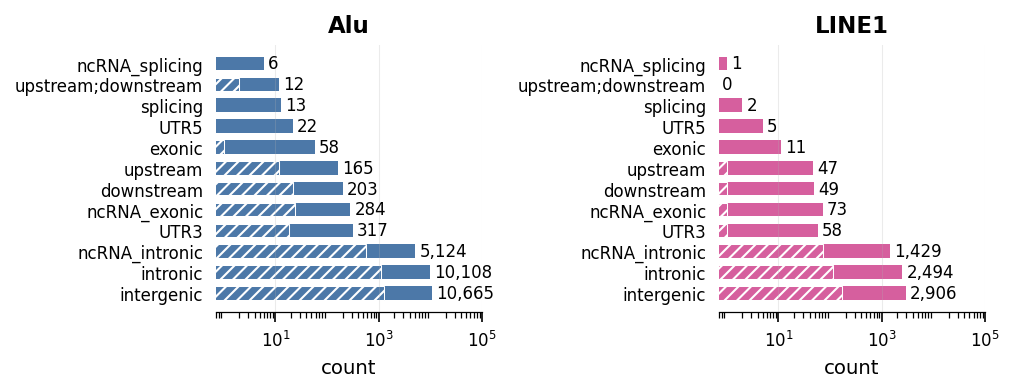


Done.


In [69]:
import os
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter, LogFormatterMathtext
import fig_style as S

S.set_style()

ALU_ANNO   = "/gpfs/data/user/shreyags/TE_work/replication_results/insertions_annotations/ALU_ensGene_annovar.hg38_multianno.txt"
LINE1_ANNO = "/gpfs/data/user/shreyags/TE_work/replication_results/insertions_annotations/LINE1_ensGene_annovar.hg38_multianno.txt"

ALU_ANNO_COMMON   = "/gpfs/data/user/shreyags/TE_work/replication_results/insertions_annotations/common/ALU_ensGene_annovar.hg38_multianno.txt"
LINE1_ANNO_COMMON = "/gpfs/data/user/shreyags/TE_work/replication_results/insertions_annotations/common/LINE1_ensGene_annovar.hg38_multianno.txt"

OUTDIR = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/figures/figure2/"
os.makedirs(OUTDIR, exist_ok=True)

TE_KEY_TO_PALETTE_KEY = {"ALU": "Alu", "LINE1": "LINE1"}

TE_DISPLAY_LABEL = {"ALU": "Alu", "LINE1": "LINE1"}
COMMON_HATCH = "////"  

def load_func_counts(anno_path):
    df = pd.read_csv(anno_path, sep="\t", dtype=str, low_memory=False)
    needed = {"Func.ensGene"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"{anno_path} missing columns: {missing}")

    counts = Counter(df["Func.ensGene"])
    print(f"[anno] {os.path.basename(anno_path)}: {len(df):,} variants, "
          f"{len(counts)} distinct categories")
    return counts


def load_func_counts_safe(anno_path, label):
    """Like load_func_counts, but doesn't hard-fail the whole script if
    the 'common' file path above turns out to be wrong -- prints a clear
    warning and returns empty counts (bars just won't show a common
    highlight) instead."""
    if not os.path.exists(anno_path):
        print(f"[warn] {label} common-subset file not found at '{anno_path}' -- "
              f"the common-variant highlight will be skipped for this TE. "
              f"Fix ALU_ANNO_COMMON/LINE1_ANNO_COMMON above.")
        return Counter()
    return load_func_counts(anno_path)

#PLOT 

def plot_genomic_distribution(counts_all_by_te, counts_common_by_te, te_order):
    tes_present = [t for t in te_order if t in counts_all_by_te]
    if not tes_present:
        print("  [warn] no TE types to plot")
        return None

    pooled = Counter()
    for c in counts_all_by_te.values():
        pooled.update(c)
    category_order = [cat for cat, _ in pooled.most_common()]

    n = len(tes_present)
    fig, axes = plt.subplots(1, n, facecolor="white", squeeze=False,
                              figsize=(S.COL2, S.COL2 * 0.42))

    for i, te in enumerate(tes_present):
        ax = axes[0][i]
        counts_all = counts_all_by_te[te]
        counts_common = counts_common_by_te.get(te, Counter())
        bar_color = S.TE_PALETTE[TE_KEY_TO_PALETTE_KEY[te]]

        values_all = [counts_all.get(cat, 0) for cat in category_order]
        values_common = [counts_common.get(cat, 0) for cat in category_order]
        y = np.arange(len(category_order))
        nonzero_mask = [v > 0 for v in values_all]
        plot_values_all = [v if v > 0 else np.nan for v in values_all]
        plot_values_common = [
            (min(vc, va) if va > 0 else np.nan)
            for vc, va in zip(values_common, values_all)
        ]

        ax.barh(y, plot_values_all, color=bar_color, height=0.65)

        common_mask = [v > 0 for v in values_common]
        if any(common_mask):
            ax.barh(
                [yi for yi, m in zip(y, common_mask) if m],
                [v for v, m in zip(plot_values_common, common_mask) if m],
                color=bar_color, hatch=COMMON_HATCH, edgecolor="white",
                height=0.65,
            )

        ax.set_yticks(y)
        ax.set_yticklabels(category_order)
        ax.set_xscale("log")
        max_v = max(values_all) if values_all and max(values_all) > 0 else 1
        top_power = int(np.ceil(np.log10(max_v * 4)))
        ax.set_xlim(0.7, 10 ** top_power)
        ax.xaxis.set_major_locator(LogLocator(base=10, numticks=top_power + 1))
        ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10))
        ax.xaxis.set_minor_locator(
            LogLocator(base=10, subs=np.arange(2, 10), numticks=100)
        )
        ax.xaxis.set_minor_formatter(NullFormatter())

        ax.tick_params(
            axis="x",
            which="major",
            length=5,
            width=0.8
        )
        ax.tick_params(
            axis="x",
            which="minor",
            bottom=True,
            top=False,
            length=3,
            width=0.6
        )

        ax.grid(which="major", axis="x", alpha=0.25, linewidth=0.5, zorder=0)
        #ax.grid(which="minor", axis="x", alpha=0.12, linewidth=0.3, zorder=0)

        for yi, v in zip(y, values_all):
            if v == 0:
                ax.text(
                    0.8, yi, "0",
                    va="center", ha="left",
                    fontsize=S.FS_TICK
                    )
            else:
                ax.text(
                    v * 1.2, yi, f"{v:,}",
                    va="center",
                    fontsize=S.FS_TICK
                )
        ax.set_title(TE_DISPLAY_LABEL[te], fontweight="bold")
        ax.spines["left"].set_visible(False)
        ax.tick_params(left=False)
        ax.set_xlabel("count")

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    return fig

alu_counts_all   = load_func_counts(ALU_ANNO)
line1_counts_all = load_func_counts(LINE1_ANNO)
alu_counts_common   = load_func_counts_safe(ALU_ANNO_COMMON, "ALU")
line1_counts_common = load_func_counts_safe(LINE1_ANNO_COMMON, "LINE1")

counts_all_by_te = {"ALU": alu_counts_all, "LINE1": line1_counts_all}
counts_common_by_te = {"ALU": alu_counts_common, "LINE1": line1_counts_common}
te_order = ["ALU", "LINE1"]

fig = plot_genomic_distribution(counts_all_by_te, counts_common_by_te, te_order)
if fig:
    S.save(fig, os.path.join(OUTDIR, "panel_A_genomic_distribution_ANNOVAR"))
    plt.show()

print("\nDone.")

p<=0.05 filter: kept 5152/10160 tissue-level observations
  saved /gpfs/data/user/shreyags/TE_work/new_results/manuscript/figures/figure2/panel_B_box_insertions_only.pdf / .png


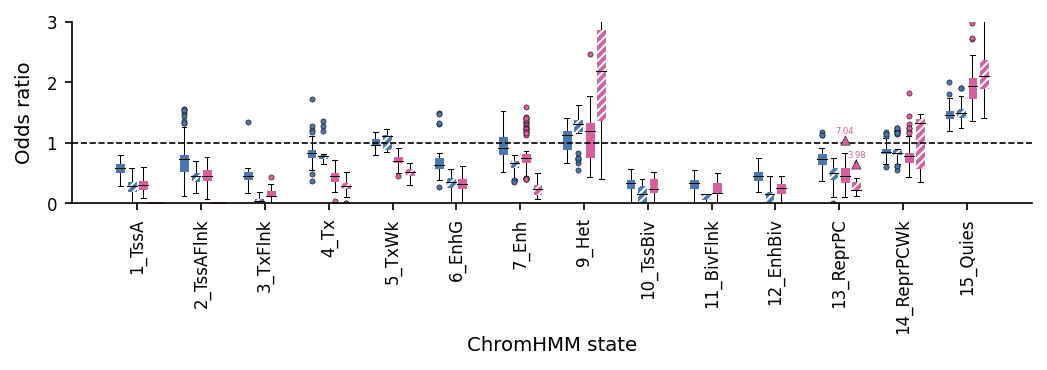

Saved to /gpfs/data/user/shreyags/TE_work/new_results/manuscript/figures/figure2


In [63]:
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import fig_style as S

S.set_style()

_LINE_RCPARAMS = [
    "axes.linewidth", "xtick.major.width", "ytick.major.width",
    "xtick.major.size", "ytick.major.size", "lines.linewidth", "patch.linewidth",
]
for _k in _LINE_RCPARAMS:
    mpl.rcParams[_k] = mpl.rcParamsDefault[_k]

FIG_WIDTH_IN = S.COL2
FIG_HEIGHT_IN = S.COL2 * 0.34
assert FIG_HEIGHT_IN <= S.MAXH, (
    f"panel height {FIG_HEIGHT_IN:.2f}in exceeds fig_style's MAXH "
    f"({S.MAXH:.2f}in) -- shrink FIG_HEIGHT_IN's multiplier"
)

LEFT, RIGHT = 0.06, 0.995  
MAIN_BOTTOM = 0.44       
MAIN_TOP = 0.96

INS_PATH = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/supplementary_tables/combined_enrichment_results.csv"


def load_arm(path):
    if not os.path.exists(path):
        print(f"[skip] file not found at '{path}'")
        return pd.DataFrame(columns=["dataset", "te_type", "category", "tissue_name", "odds_ratio", "pvalue"])
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f"[skip] failed to read '{path}' ({e})")
        return pd.DataFrame(columns=["dataset", "te_type", "category", "tissue_name", "odds_ratio", "pvalue"])


df = load_arm(INS_PATH)

if df.empty:
    raise RuntimeError("Insertions data could not be loaded — nothing to plot.")

n_before = len(df)
df = df[df["pvalue"] <= 0.05].copy()
print(f"p<=0.05 filter: kept {len(df)}/{n_before} tissue-level observations")

TE_KEY_TO_PALETTE_KEY = {"ALU": "Alu", "LINE1": "LINE1"}
COLOURS = {k: S.TE_PALETTE[v] for k, v in TE_KEY_TO_PALETTE_KEY.items()}

state_order = [
    "1_TssA", "2_TssAFlnk", "3_TxFlnk", "4_Tx", "5_TxWk", "6_EnhG", "7_Enh",
    "8_ZNF/Rpts", "9_Het", "10_TssBiv", "11_BivFlnk", "12_EnhBiv",
    "13_ReprPC", "14_ReprPCWk", "15_Quies",
]
present_states = [s for s in state_order if s in df["category"].unique()]
if not present_states:
    present_states = sorted(df["category"].dropna().unique())

n_states = len(present_states)

SUBGROUPS = [
    ("ALU",   "all"),
    ("ALU",   "common"),
    ("LINE1", "all"),
    ("LINE1", "common"),
]
n_sub = len(SUBGROUPS)
box_width = 0.18
OFFSETS = [(i - (n_sub - 1) / 2) * box_width for i in range(n_sub)]

fig = plt.figure(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN))
ax = fig.add_axes([LEFT, MAIN_BOTTOM, RIGHT - LEFT, MAIN_TOP - MAIN_BOTTOM])

for si, state in enumerate(present_states):
    state_df = df[df["category"] == state]

    for gi, (te, dataset) in enumerate(SUBGROUPS):
        colour = COLOURS[te]
        hatch = "//////" if dataset == "common" else None
        x_pos = si + OFFSETS[gi]

        sub = state_df[
            (state_df["te_type"] == te) &
            (state_df["dataset"] == dataset)
        ]["odds_ratio"].dropna()

        if len(sub) < 2:
            if len(sub) == 1:
                ax.plot(x_pos, sub.values[0], marker="_", color=colour,
                        markersize=8, markeredgewidth=1.2)
            continue

        bp = ax.boxplot(
            sub,
            positions=[x_pos],
            widths=box_width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            notch=False,
            showfliers=True,
            flierprops=dict(marker="o", markerfacecolor=colour,
                             markersize=2.5, linestyle="none", markeredgecolor="black", markeredgewidth=0.25, alpha=1),
            medianprops=dict(color="black", linewidth=0.5),
            whiskerprops=dict(color="black", linewidth=0.5),
            capprops=dict(color="black", linewidth=0.5),
            boxprops=dict(linewidth=0.8),
        )
        
        ylim_top = 3

        # Tukey outlier limits
        q1 = np.percentile(sub, 25)
        q3 = np.percentile(sub, 75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outliers = sub[(sub < lower) | (sub > upper)]

        # outliers beyond plotting window
        hidden = outliers[outliers > ylim_top]

        if len(hidden):

            whisker_top = bp["caps"][-1].get_ydata()[0]
            tri_y = whisker_top + 0.22

            sorted_vals = np.sort(hidden.values)
            n_hidden = len(sorted_vals)
            jitter = np.linspace(-0.04, 0.04, n_hidden) if n_hidden > 1 else np.array([0.0])

            marker_hatch = "///" if hatch else None
            marker_size = 20

            ax.scatter(
                x_pos + jitter,
                np.repeat(tri_y, n_hidden),
                marker="^",
                s=marker_size,
                facecolor=colour,
                edgecolor="black",
                linewidth=0.25,
                hatch=marker_hatch,
                clip_on=False,
                zorder=7,
            )

            for dx, val in zip(jitter, sorted_vals):
                ax.annotate(
                    f"{val:.2f}",
                    xy=(x_pos + dx, tri_y),
                    xytext=(0, 2),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=4,
                    color=colour,
                    clip_on=False,
                    annotation_clip=False,
                )

        for patch in bp["boxes"]:
            patch.set_facecolor(colour)
            patch.set_alpha(1)
            patch.set_linewidth(0.5)
            if hatch:
                patch.set_hatch(hatch)
                patch.set_edgecolor("white")
            else:
                patch.set_edgecolor("white")

ax.set_ylim(0, 3)
ax.axhline(y=1, linestyle="--", linewidth=0.8, color="black")
ax.set_xticks(range(n_states))
ax.set_xticklabels(present_states, rotation=90)
ax.set_xlabel("ChromHMM state", labelpad=1)
ax.set_ylabel("Odds ratio", labelpad=6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

OUTDIR = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/figures/figure2"
os.makedirs(OUTDIR, exist_ok=True)

S.save(fig, os.path.join(OUTDIR, "panel_B_box_insertions_only"))
plt.show()

print(f"Saved to {OUTDIR}")

In [1]:
import os
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageDraw, ImageFont

import fig_style as S

FIGDIR = "/gpfs/data/user/shreyags/TE_work/new_results/manuscript/figures/figure2"

PANEL_A_PATH = os.path.join(FIGDIR, "panel_A_genomic_distribution_ANNOVAR.png")
PANEL_B_PATH = os.path.join(FIGDIR, "panel_B_box_insertions_only.png")
LEGEND_BASENAME = os.path.join(FIGDIR, "shared_legend") 
LEGEND_PATH = LEGEND_BASENAME + ".png"

OUT_PNG = os.path.join(FIGDIR, "figure2_combined.png")
OUT_PDF = os.path.join(FIGDIR, "figure2_combined.pdf")

DPI = 300
GAP_PX = 5
BACKGROUND = (255, 255, 255)
LABEL_MARGIN_PX = 10

COMMON_HATCH = "////"
TE_KEY_TO_PALETTE_KEY = {"ALU": "Alu", "LINE1": "LINE1"}

EXPECTED_WIDTH_PX = round(S.COL2 * DPI)

def build_shared_legend(basename):
    S.set_style()
    fig = plt.figure(figsize=(S.COL2, S.COL2 * 0.08), facecolor="white")

    ax = fig.add_axes([0, 0, 1, 1])
    ax.axis("off")

    legend_font = fm.FontProperties(
        family=plt.rcParams["font.family"],
        weight=plt.rcParams.get("font.weight", "normal"),
        size=plt.rcParams["legend.fontsize"],
    )
    legend_title_font = fm.FontProperties(
        family=plt.rcParams["font.family"],
        weight=plt.rcParams.get("font.weight", "normal"),
        size=plt.rcParams.get("legend.title_fontsize", plt.rcParams["legend.fontsize"]),
    )

    te_handles = [
        mpatches.Patch(facecolor=S.TE_PALETTE[TE_KEY_TO_PALETTE_KEY[te]],
                        edgecolor="none", label=te)
        for te in ["ALU", "LINE1"]
    ]
    dataset_handles = [
        mpatches.Patch(facecolor="grey", edgecolor="none", label="all"),
        mpatches.Patch(facecolor="grey", edgecolor="white", hatch=COMMON_HATCH, label="common"),
    ]

    leg1 = ax.legend(handles=te_handles, title="TE type", loc="center left",
                      bbox_to_anchor=(0.05, 0.5), ncol=2, frameon=False,
                      prop=legend_font, title_fontproperties=legend_title_font)
    ax.add_artist(leg1)
    ax.legend(handles=dataset_handles, title="Dataset", loc="center right",
              bbox_to_anchor=(0.95, 0.5), ncol=2, frameon=False,
              prop=legend_font, title_fontproperties=legend_title_font)

    S.save(fig, basename)
    plt.close(fig)
    print(f"[legend] saved {basename}.png")

def find_label_font(size_px):
    have_arial = any(f.name == "Arial" for f in fm.fontManager.ttflist)
    family = "Arial" if have_arial else "DejaVu Sans"
    try:
        font_path = fm.findfont(fm.FontProperties(family=family, weight="bold"), fallback_to_default=True)
        return ImageFont.truetype(font_path, size_px)
    except Exception as e:
        print(f"[warn] couldn't load a bold {family} font ({e}), falling back to PIL default")
        return ImageFont.load_default()


def load_panel(path, expected_width_px=EXPECTED_WIDTH_PX):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{path} not found -- run that panel's own script first "
            f"(it needs to save its PNG before this assembler can use it)."
        )
    img = Image.open(path).convert("RGB")
    print(f"[load] {os.path.basename(path)}: {img.width}x{img.height}px")

    if img.width != expected_width_px:
        print(f"    [warn] {os.path.basename(path)} is {img.width}px wide, expected "
              f"{expected_width_px}px (S.COL2={S.COL2}in @ {DPI}dpi)")
        scale = expected_width_px / img.width
        new_size = (expected_width_px, round(img.height * scale))
        img = img.resize(new_size, Image.LANCZOS)

    return img


def assemble(panels, gap_px=GAP_PX, background=BACKGROUND):
    """panels: list of (path, label_or_None) -- label=None means no
    letter is drawn for that image (used for the shared legend strip)."""
    loaded = [(load_panel(p), label) for p, label in panels]

    widths = {img.width for img, _ in loaded}
    if len(widths) > 1:
        print(f"[warn] panels have DIFFERENT widths even after normalization: "
              f"{[img.width for img, _ in loaded]}")
    canvas_width = max(widths)
    canvas_height = sum(img.height for img, _ in loaded) + gap_px * (len(loaded) - 1)

    canvas = Image.new("RGB", (canvas_width, canvas_height), background)
    draw = ImageDraw.Draw(canvas)

    label_size_px = round(S.FS_PANEL * DPI / 72)
    font = find_label_font(label_size_px)

    y_cursor = 0
    for img, label in loaded:
        canvas.paste(img, (0, y_cursor))
        if label:
            draw.text((LABEL_MARGIN_PX, y_cursor + LABEL_MARGIN_PX), label,
                       fill=(0, 0, 0), font=font)
        y_cursor += img.height + gap_px

    return canvas


def main():
    build_shared_legend(LEGEND_BASENAME)

    panels = [
        (PANEL_A_PATH, "A"),
        (PANEL_B_PATH, "B"),
        (LEGEND_PATH, None),  # shared legend, no letter
    ]
    canvas = assemble(panels)

    canvas.save(OUT_PNG, dpi=(DPI, DPI))
    print(f"\nsaved {OUT_PNG}  ({canvas.width}x{canvas.height}px)")

    canvas.save(OUT_PDF, resolution=DPI)
    print("\nDone.")


if __name__ == "__main__":
    main()

  saved /gpfs/data/user/shreyags/TE_work/new_results/manuscript/figures/figure2/shared_legend.pdf / .png
[legend] saved /gpfs/data/user/shreyags/TE_work/new_results/manuscript/figures/figure2/shared_legend.png
[load] panel_A_genomic_distribution_ANNOVAR.png: 2055x863px
[load] panel_B_box_insertions_only.png: 2055x698px
[load] shared_legend.png: 2055x164px

saved /gpfs/data/user/shreyags/TE_work/new_results/manuscript/figures/figure2/figure2_combined.png  (2055x1735px)

Done.
